# NB09 - Operational Translation: Routing Decisions, Delinquency Capture & Review Stability

---

## Notebook Purpose and Scientific Role

NB09 covers the following practical question:

> When CP prediction sets are interpreted as routing instructions, do these
> reliability differences translate into operationally meaningful differences in
> false auto-clear risk, delinquency capture, review burden, and workload stability?

This is the operational translation layer of the thesis. It asks how prediction sets
change screening dispositions and whether they improve **selection efficiency** relative
to the calibrated-probability ranking.

### Theoretical grounding

This translation is grounded in:
- reject-option classification (Chow, 1957; Herbei & Wegkamp, 2006),
- selective classification / risk-coverage analysis (El-Yaniv & Wiener, 2010; Geifman & El-Yaniv, 2017; Franc et al., 2023),
- and decision-theoretic conformal prediction (Kiyani et al., 2025), which explicitly
  motivates evaluating prediction sets by the actions they induce.

### Scope of NB09: methods evaluated

NB09 evaluates **SCP, Mondrian (FICO×LTV), and APS** - the three static CP methods
that appear throughout NB06–NB08. DtACI and the ACI-γ variants are deliberately excluded
from NB09 for the following structural reason: their effective threshold q_t changes
sequentially each month as coverage feedback is incorporated (Gibbs & Candès, 2021, 2024).
At any single time step the Δ ≈ 0 monotone argument still holds within that month, but
aggregated over a regime with time-varying q_t the relationship between the CP routing
decision and a fixed p̂_cal ranking is no longer a simple identity. An operational
evaluation of DtACI/ACI would require a time-aware treatment - tracking monthly threshold
trajectories and their staffing implications - which lies outside the scope of this notebook.

*Legacy display label.* Some stored exploratory outputs use `Subprime (2007–12)` for
the thesis's **Crisis 2007–12** window; the internal split key remains `test_subprime`.

---

## Routing semantics used in NB09

For each observation, the prediction set is translated into a queue:

- `{0}` → **auto-clear**
- `∅` or `{0,1}` → **manual review**
- `{1}` → **high-risk flag / escalation**

For SCP and Mondrian, review corresponds to the **empty set** (neither y=0 nor y=1 covered).
For APS, review corresponds to the **ambiguous set `{0,1}`** (both labels covered).

### Critical threshold asymmetry

The APS auto-clear boundary is approximately `p̂_cal < 1 - q̂_APS`, versus the SCP
auto-clear boundary `p̂_cal ≤ q̂_SCP`. Based on NB05b calibration results,
the APS auto-clear threshold is typically several times higher than SCP's
(the exact ratio is printed in §1.1).

Because the APS auto-clear zone is wider, a larger fraction of future delinquents fall into
it, which is the mechanism behind APS's higher false auto-clear rate. Section 3 develops this
causal chain in full.

---

## Notebook Structure

| § | Title | Description |
|---|---|---|
| **0** | Setup & Configuration | Dependencies, paths, manifests, thresholds, split metadata, sampling conventions |
| **1** | Load Artefacts & Build Routing Dataset | Load score/evaluation artefacts and the per-row `p̂_cal`, derive routing states and regime-level operational dataset |
| **2** | Three-Way Routing Confusion Tables | Compute routing-state × outcome tables and core operational metrics |
| **3** | False Auto-Clear and Delinquency Capture | False-auto-clear and capture results; method-by-regime comparison |
| **4** | Queue Contraction Translated into Delinquency Terms | Convert queue-size differences into missed/captured delinquency counts |
| **5** | Review-Budget Curves | Compare natural CP operating points with top-k probability-threshold baselines |
| **6** | Matched Non-Auto-Clear Budget Comparison | Formal Δ comparison at matched non-auto-clear budget |
| **7** | Subgroup Review Burden and Targeting Quality | FICO×LTV burden, review precision, and targeting diagnostics |
| **8** | Monthly Workload Stability | Queue-size stability over time and staffing-relevant variation |
| **9** | Cost-Based Comparison | Expected-cost comparisons under review-cost / false-negative-cost sweeps |
| **10** | Locked Operational Findings | Final thesis decisions and the consolidated operational-findings summary (CSV artefacts are exported across §2-§9) |
| **App.** | References | APA 7th-edition citations for all sources cited in this notebook |

---

## Role of this notebook in the thesis

NB09 is the thesis's operational decision-layer notebook. It asks how the resulting prediction sets translate into routing and whether they improve
matched-budget selection.

Its core contribution is therefore the separation between:
- **statistical reliability**,
- and **routing semantics and selection efficiency** relative to calibrated-score thresholding.

Better statistical reliability does not automatically imply better selection efficiency.

---
## Section 0 · Setup & Configuration

In [ ]:
%pip install -q polars pyarrow

import json, os, sys, warnings
from datetime import datetime, timezone
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl

warnings.filterwarnings("ignore", category=FutureWarning)

print(f"Polars    : {pl.__version__}")
print(f"Pandas    : {pd.__version__}")
print(f"NumPy     : {np.__version__}")
print(f"Matplotlib: {mpl.__version__}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 847.1/847.1 kB 29.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 MB 71.8 MB/s eta 0:00:00
Polars    : 1.43.2
Pandas    : 2.2.2
NumPy     : 2.0.2
Matplotlib: 3.10.0


In [ ]:
from google.colab import drive
drive.mount("/content/drive", force_remount=False)
DRIVE_ROOT = Path("/content/drive/MyDrive/master_thesis")

RESULTS_DIR  = DRIVE_ROOT / "results"
SCORES_DIR   = RESULTS_DIR / "scores"
NB07_OUT_DIR = RESULTS_DIR / "nb07"
NB08_OUT_DIR = RESULTS_DIR / "nb08"
NB09_OUT_DIR = RESULTS_DIR / "nb09"
MANIFEST_DIR = DRIVE_ROOT / "manifests"
NB09_OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR = NB09_OUT_DIR / "figures"
FIG_DIR.mkdir(exist_ok=True)

CP_MANIFEST_PATH   = MANIFEST_DIR / "cp_manifest.json"
# Legacy NB07 path retained as an execution-time integrity check only;
# NB09 does not consume its contents.
NB07_MANIFEST_PATH = MANIFEST_DIR / "analysis_manifest.json"
NB08_MANIFEST_PATH = MANIFEST_DIR / "audit_manifest.json"

for p in [CP_MANIFEST_PATH, NB07_MANIFEST_PATH, NB08_MANIFEST_PATH, SCORES_DIR]:
    assert p.exists(), f"Required upstream path missing: {p}"
    print(f"  ✓  {p.name if p.is_file() else p}")

with open(NB08_MANIFEST_PATH) as f: NB08_MANIFEST = json.load(f)

Mounted at /content/drive
  ✓  cp_manifest.json
  ✓  analysis_manifest.json
  ✓  audit_manifest.json
  ✓  /content/drive/MyDrive/master_thesis/results/scores


In [ ]:
# ── Global constants ────────────────────────────────────────────────────────
ALPHA        = 0.10
FIG_DPI      = 300
SAMPLE_FRAC  = 0.05        # 5% hash-based loan-level sample
N_HASH_BUCKETS = 1000

AUDIT_METHODS = ["scp", "mondrian_fico_ltv", "aps"]
METHOD_LABELS = {
    "scp"             : "SCP",
    "mondrian_fico_ltv": "Mondrian (FICO×LTV)",
    "aps"             : "APS",
}
METHOD_COLORS = {
    "scp"             : "#2d3436",
    "mondrian_fico_ltv": "#0984e3",
    "aps"             : "#6c5ce7",
}

TEST_SPLITS = ["test_subprime", "test_normal", "test_covid", "test_rate_hike"]
SPLIT_LABELS = {
    "test_subprime"  : "Subprime (2007–12)",
    "test_normal"    : "Normal (2013–19)",
    "test_covid"     : "COVID (2020–21)",
    "test_rate_hike" : "Rate Hike (2022–23)",
}
SPLIT_MECH = {
    "test_subprime"  : "Tail Shift",
    "test_normal"    : "Stable",
    "test_covid"     : "Structural Shift",
    "test_rate_hike" : "Composition Shift",
}
SPLIT_COLORS = {
    "test_subprime"  : "#e17055",
    "test_normal"    : "#00b894",
    "test_covid"     : "#fdcb6e",
    "test_rate_hike" : "#74b9ff",
}

REVIEW_BUDGET_MAX_PCT = 20.0  # x-axis limit for budget curves (% of portfolio)

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,

    # Explicit publication-black structural elements
    "text.color": "#000000",
    "axes.labelcolor": "#000000",
    "axes.edgecolor": "#000000",
    "axes.titlecolor": "#000000",
    "xtick.color": "#000000",
    "ytick.color": "#000000",
    "legend.labelcolor": "#000000",

    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,

    "figure.facecolor": "white",
    "axes.facecolor": "white",

    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linewidth": 0.5,

    "savefig.dpi": FIG_DPI,

    # Vector PDF font embedding
    "pdf.fonttype": 42,
})

print(f"Sample fraction : {SAMPLE_FRAC*100:.0f}% per regime")
print(f"Methods         : {AUDIT_METHODS}")

Sample fraction : 5% per regime
Methods         : ['scp', 'mondrian_fico_ltv', 'aps']


---
## Section 1 · Load Artefacts & Build Routing Dataset

### Routing threshold derivation

Routing decisions are derived analytically from the calibrated probability $\hat{\text{p}}\text{_cal}$, which is loaded directly from the per-row `p̂_cal` column written by NB05a (the isotonically calibrated $P(Y=1|X)$).

**SCP and Mondrian** use the empty-set formulation (Vovk et al., 2005, for the conformal set construction; Papadopoulos et al., 2002, for split-conformal calibration. The score s(x,y) = 1 − p̂_cal(y|x) follows Sadinle et al., 2019):
$$y \in \hat{C}(x) \iff s(x,y) \leq \hat{q} \iff 1 - \hat{p}_{\text{cal}}(y|x) \leq \hat{q}$$

Binary set types:
- `{0}`: $\hat{p}_{\text{cal}} \leq \hat{q}$ (y=0 covered, y=1 not) → **auto-clear**
- `∅`: $\hat{q} < \hat{p}_{\text{cal}} < 1 - \hat{q}$ (neither covered) → **review**
- `{1}`: $\hat{p}_{\text{cal}} \geq 1 - \hat{q}$ (y=1 covered, y=0 not) → **high-risk flag**

**APS** uses the GIQ score (Romano, Sesia & Candès, 2020). In binary classification,
the GIQ-based prediction set (using the deterministic U=1 variant) yields:
- `{0}`: $\hat{p}_{\text{cal}} < 1 - \hat{q}_{\text{APS}}$ → **auto-clear**
- `{0,1}`: $1-\hat{q}_{\text{APS}} \leq \hat{p}_{\text{cal}} \leq \hat{q}_{\text{APS}}$ → **review** (ambiguous)
- `{1}`: $\hat{p}_{\text{cal}} > \hat{q}_{\text{APS}}$ → **high-risk flag**

*Routing convention.* NB09 evaluates APS as a **deterministic operational policy**: the auto-clear / review / flag decision is the U=1 (non-randomized) reduction of the GIQ set, so a loan-month's routing never depends on a random draw. This makes the operational disposition reproducible for a given loan-month. It also differs from the randomized APS prediction sets used for the coverage analysis (NB06–NB08), where a fresh U is drawn per observation per the Romano et al. (2020) construction. The two are not interchangeable: the deterministic policy here is a monotone threshold on p̂_cal, whereas the randomized sets vary set membership around the q̂_APS boundary. The FAC, capture, and review-rate figures in NB09 therefore characterise this deterministic policy and should be cited alongside the randomized-APS coverage results in NB07.

The `{0,1}` APS set and SCP's `∅` set are both treated here as non-committal
dispositions and routed to manual review. The key difference is *which loan-months*
each rule sends to review.

### The APS review queue is a small middle band

The APS review queue is the **middle-band ambiguity region** between $(1-\hat q_{\text{APS}})$
and $( \hat q_{\text{APS}} )$. Given the empirical score distribution in this mortgage setting,
that band contains only a small share of observations, so NB09 evaluates APS as a
**high-precision / low-review** policy.

### Threshold asymmetry

The exact threshold values and ratio are printed at runtime in §1.1 from `cp_manifest.json`.
Indicatively (based on NB05b calibration):
- q̂_SCP is small → auto-clear if p̂_cal ≤ q̂_SCP
- q̂_APS is large (≈ 1 - α) → auto-clear if p̂_cal < 1 - q̂_APS

This means APS's auto-clear zone is substantially wider than SCP's in probability space.
The Mondrian FICO×LTV thresholds span a wide range across cells, reflecting the per-cell calibration.

NB08's 5% `p_hat_cal` split is loaded only as a descriptive cross-reference.


In [ ]:
# ── 1.1 · Load upstream manifests and thresholds ────────────────────────────
with open(CP_MANIFEST_PATH) as f: CP_MANIFEST = json.load(f)

# Routing thresholds (float32 precision per NB05b contract)
Q_SCP = np.float32(CP_MANIFEST["scp"]["q_hat"])
Q_APS = np.float32(CP_MANIFEST["aps"]["q_hat"])
MOND_THRESHOLDS = {
    k: np.float32(v) for k, v in CP_MANIFEST["mondrian"]["fico_ltv"].items()
}

# APS routing thresholds
APS_AUTO_CLEAR_THRESH  = np.float32(1.0 - Q_APS)   # p_hat < this → auto-clear
APS_HIGH_RISK_THRESH   = Q_APS                     # p_hat > this → high-risk

print(f"Routing thresholds (float32):")
print(f"  SCP  : auto_clear if p_hat ≤ {Q_SCP:.5f}  |  high_risk if p_hat ≥ {1-Q_SCP:.5f}")
print(f"  APS  : auto_clear if p_hat < {APS_AUTO_CLEAR_THRESH:.5f}  |  review if [{APS_AUTO_CLEAR_THRESH:.5f}, {APS_HIGH_RISK_THRESH:.5f}]  |  high_risk if p_hat > {APS_HIGH_RISK_THRESH:.5f}")
print(f"  APS auto-clear threshold is {APS_AUTO_CLEAR_THRESH/Q_SCP:.1f}x higher than SCP threshold")
print()
print("Mondrian FICO×LTV thresholds:")
for cell, q in sorted(MOND_THRESHOLDS.items()):
    print(f"  {cell:<32}: q={float(q):.5f}")

assert "aps_risk_tail_threshold" in NB08_MANIFEST, (
    "nb08_manifest is missing required key 'aps_risk_tail_threshold'. "
    "NB08 must record this threshold for the NB09 routing analysis."
)
APS_RISK_TAIL_THRESHOLD = float(NB08_MANIFEST["aps_risk_tail_threshold"])
print(f"\nNB08 APS low-risk-tail threshold: p_hat_cal < {APS_RISK_TAIL_THRESHOLD:.2f} (carried into the routing analysis)")

Routing thresholds (float32):
  SCP  : auto_clear if p_hat ≤ 0.01622  |  high_risk if p_hat ≥ 0.98378
  APS  : auto_clear if p_hat < 0.10005  |  review if [0.10005, 0.89995]  |  high_risk if p_hat > 0.89995
  APS auto-clear threshold is 6.2x higher than SCP threshold

Mondrian FICO×LTV thresholds:
  Near-Prime × High               : q=0.07071
  Near-Prime × Low                : q=0.01784
  Near-Prime × Moderate           : q=0.05414
  Prime × High                    : q=0.01799
  Prime × Low                     : q=0.00326
  Prime × Moderate                : q=0.01246
  Sentinel                        : q=0.01853
  Subprime × High                 : q=0.42010
  Subprime × Low                  : q=0.16907
  Subprime × Moderate             : q=0.38339

NB08 APS low-risk-tail threshold: p_hat_cal < 0.05 (carried into the routing analysis)


In [ ]:
# ── 1.2 · Load 5% hash-sample score files ───────────────────────────────────
# Sampling uses zlib.crc32(loan_sequence_number) % N_HASH_BUCKETS < N_KEEP, identical to
# NB08, so NB08 and NB09 select byte-identical rows. crc32 is deterministic across
# sessions and machines. N_KEEP / N_HASH_BUCKETS = 50/1000 = 5% sample rate.
import zlib

SCORE_COLS = [
    "loan_sequence_number", "obs_month", "obs_year",
    "y", "p_hat_cal", "score_scp", "score_aps",
    "fico_tier", "ltv_bucket", "fico_ltv_group", "census_division",
]
N_KEEP = round(SAMPLE_FRAC * N_HASH_BUCKETS)

def load_split_sample(split: str) -> pl.DataFrame:
    split_dir    = SCORES_DIR / f"split={split}"
    parquet_files = sorted(split_dir.glob("*.parquet"))
    assert parquet_files, f"No parquet files in {split_dir}"

    lf = pl.scan_parquet([str(f) for f in parquet_files], hive_partitioning=False)
    schema_cols = lf.collect_schema().names()
    load_cols   = [c for c in SCORE_COLS if c in schema_cols]

    df = lf.select(load_cols).collect()

    hashes = df["loan_sequence_number"].cast(pl.Utf8).to_list()
    mask   = np.array(
        [zlib.crc32(s.encode()) % N_HASH_BUCKETS < N_KEEP for s in hashes],
        dtype=bool,
    )
    return df.filter(pl.Series("_mask", mask)).with_columns(pl.lit(split).alias("split"))

print(f"Loading {SAMPLE_FRAC*100:.0f}% hash-sample...")
split_dfs = {}
for split in TEST_SPLITS:
    print(f"  {split}...", end=" ", flush=True)
    split_dfs[split] = load_split_sample(split)
    print(f"{len(split_dfs[split]):,} rows | {split_dfs[split]['y'].mean()*100:.2f}% y=1")

ALL_DF = pl.concat(list(split_dfs.values()), how="diagonal")
print(f"\nTotal rows: {len(ALL_DF):,}")

Loading 5% hash-sample...
  test_subprime... 31,692,753 rows | 2.53% y=1
  test_normal... 37,785,626 rows | 1.53% y=1
  test_covid... 10,079,140 rows | 1.67% y=1
  test_rate_hike... 15,312,169 rows | 1.04% y=1

Total rows: 94,869,688


In [ ]:
# ── 1.3 · Load p_hat_cal and compute routing for all methods ─────────────────

df_pd = ALL_DF.to_pandas()

# Calibrated delinquency probability
assert "p_hat_cal" in df_pd.columns, (
    "p_hat_cal column not found in score files; expected from NB05a score generation."
)
df_pd["p_hat_cal"] = df_pd["p_hat_cal"].astype(np.float32)

# ── SCP routing ───────────────────────────────────────────────────────────────
q_scp_f = float(Q_SCP)
df_pd["scp_route"] = np.where(
    df_pd["p_hat_cal"] <= q_scp_f, "auto_clear",
    np.where(df_pd["p_hat_cal"] >= 1.0 - q_scp_f, "high_risk", "review")
)

# ── Mondrian routing (group-specific thresholds) ──────────────────────────────
def mondrian_route(p_hat: np.ndarray, groups: pd.Series) -> np.ndarray:
    q_vals  = np.array([float(MOND_THRESHOLDS.get(g, Q_SCP))
                        for g in groups], dtype=np.float32)
    routes  = np.where(p_hat <= q_vals, "auto_clear",
              np.where(p_hat >= 1.0 - q_vals, "high_risk", "review"))
    return routes

df_pd["mond_route"] = mondrian_route(df_pd["p_hat_cal"].values, df_pd["fico_ltv_group"])

_mond_keys  = set(MOND_THRESHOLDS.keys())
_in_keys    = df_pd["fico_ltv_group"].isin(_mond_keys)
_n_fallback = int((~_in_keys).sum())
_missing    = sorted(set(df_pd.loc[~_in_keys, "fico_ltv_group"].dropna().unique()))
if _n_fallback:
    print(f"  WARNING: {_n_fallback:,} rows ({_n_fallback/len(df_pd)*100:.3f}%) "
          f"have no cell-specific Mondrian threshold and fall back to Q_SCP. "
          f"Cells without a threshold: {_missing}")
else:
    print("  All observed FICO×LTV cells have a calibrated Mondrian threshold (no Q_SCP fallback).")

# ── APS routing ───────────────────────────────────────────────────────────────
q_aps_f  = float(Q_APS)
aps_lo   = float(APS_AUTO_CLEAR_THRESH)   # 1 - q_hat_APS
df_pd["aps_route"] = np.where(
    df_pd["p_hat_cal"] < aps_lo, "auto_clear",
    np.where(df_pd["p_hat_cal"] > q_aps_f, "high_risk", "review")
)

# Route column map for iteration
ROUTE_COLS = {
    "scp"             : "scp_route",
    "mondrian_fico_ltv": "mond_route",
    "aps"             : "aps_route",
}

# Verify routing distributions
print("Routing distributions (5% sample):")
print(f"{'Method':<22} {'Regime':<22} {'auto_clear':>12} {'review':>10} {'high_risk':>11}")
print("-" * 78)
for method, rcol in ROUTE_COLS.items():
    for split in TEST_SPLITS:
        sub = df_pd[df_pd["split"] == split]
        cts = sub[rcol].value_counts(normalize=True) * 100
        ac  = cts.get("auto_clear", 0)
        rv  = cts.get("review",     0)
        hr  = cts.get("high_risk",  0)
        print(f"  {METHOD_LABELS[method]:<20} {SPLIT_LABELS[split]:<22} "
              f"{ac:>11.2f}% {rv:>9.2f}% {hr:>10.4f}%")

  All observed FICO×LTV cells have a calibrated Mondrian threshold (no Q_SCP fallback).
Routing distributions (5% sample):
Method                 Regime                   auto_clear     review   high_risk
------------------------------------------------------------------------------
  SCP                  Subprime (2007–12)           91.48%      8.52%     0.0000%
  SCP                  Normal (2013–19)             95.19%      4.81%     0.0000%
  SCP                  COVID (2020–21)              95.70%      4.30%     0.0000%
  SCP                  Rate Hike (2022–23)          96.92%      3.08%     0.0000%
  Mondrian (FICO×LTV)  Subprime (2007–12)           90.62%      9.35%     0.0327%
  Mondrian (FICO×LTV)  Normal (2013–19)             94.98%      5.00%     0.0179%
  Mondrian (FICO×LTV)  COVID (2020–21)              94.84%      5.16%     0.0047%
  Mondrian (FICO×LTV)  Rate Hike (2022–23)          95.83%      4.16%     0.0023%
  APS                  Subprime (2007–12)           97.44%  

---
## Section 2 · Three-Way Routing Confusion Tables

For each (method, regime), the three-way routing table partitions observations by
prediction set type *and* true label. This produces the fundamental operational
risk metrics (grounded in the reject-option tradition of Chow, 1957, and the selective-risk framework of Franc et al., 2023):

| Metric | Definition | Interpretation |
|--------|-----------|----------------|
| **False auto-clear rate** | P(auto-clear \| y=1) | Fraction of future delinquents waved through |
| **Delinquency capture rate** | P(review ∪ flag \| y=1) = 1 - FAC | Fraction of delinquencies routed to human scrutiny |
| **Review precision** | P(y=1 \| review) | Delinquency rate within the review queue |
| **Review lift** | P(y=1 \| review) / P(y=1) | How much more delinquency-dense is the queue vs portfolio |
| **Auto-clear contamination** | P(y=1 \| auto-clear) | Delinquency rate among auto-cleared loan-months |


In [ ]:
# ── Compute three-way routing table and derived metrics ──────────────────────
#
# For each method × regime, compute the three-way routing breakdown:
#   auto_clear | review | high_risk
# crossed with the true label y.
#
# For APS, review = the ambiguous middle band {0,1}. This produces a smaller
# natural review queue than SCP/Mondrian, so direct operational comparisons must
# be interpreted in light of the routing semantics, not only the method label.

routing_metrics = []

for method, rcol in ROUTE_COLS.items():
    for split in TEST_SPLITS:
        sub   = df_pd[df_pd["split"] == split]
        n     = len(sub)
        y     = sub["y"].values
        route = sub[rcol].values
        pos_rate = y.mean()

        ac_mask = route == "auto_clear"
        rv_mask = route == "review"
        hr_mask = route == "high_risk"

        n_ac = ac_mask.sum(); n_rv = rv_mask.sum(); n_hr = hr_mask.sum()

        # Queue composition (y=1 counts in each queue)
        y_ac = y[ac_mask]; y_rv = y[rv_mask]; y_hr = y[hr_mask]

        # ── Core metrics ──────────────────────────────────────────────────────
        n_y1 = y.sum()

        # FAC = P(auto_clear | y=1): fraction of ALL delinquents auto-cleared
        fac_precise  = y_ac.sum() / n_y1 if n_y1 > 0 else 0.0

        # Capture = P(review ∪ flag | y=1): complement of FAC
        capt_precise = (y_rv.sum() + y_hr.sum()) / n_y1 if n_y1 > 0 else 0.0

        # Review precision = P(y=1 | review): delinquency rate in the review queue
        rv_prec  = y_rv.mean() if n_rv > 0 else 0.0

        # Review lift: how much more delinquency-dense is the review queue vs portfolio
        rv_lift  = rv_prec / pos_rate if pos_rate > 0 else 0.0

        # Auto-clear contamination = P(y=1 | auto_clear): delinquency density in the auto-clear queue
        # DISTINCT from FAC = P(auto_clear | y=1) - see comment above.
        ac_cont  = y_ac.mean() if n_ac > 0 else 0.0

        routing_metrics.append({
            "method"       : method,
            "split"        : split,
            "mechanism"    : SPLIT_MECH[split],
            "n"            : n,
            "pos_rate_pct" : pos_rate * 100,
            "ac_rate_pct"  : n_ac / n * 100,
            "rv_rate_pct"  : n_rv / n * 100,
            "hr_rate_pct"  : n_hr / n * 100,
            # y=1 raw counts in each queue (5% sample)
            "n_y1_ac"      : int(y_ac.sum()),
            "n_y1_rv"      : int(y_rv.sum()),
            "n_y1_hr"      : int(y_hr.sum()),
            # Operational metrics
            "fac_pct"         : fac_precise * 100,      # FAC = P(auto_clear | y=1)
            "capture_pct"     : capt_precise * 100,     # capture = P(review ∪ flag | y=1)
            "rv_precision_pct": rv_prec * 100,          # P(y=1 | review)
            "rv_lift"         : rv_lift,                # precision / portfolio base rate
            "ac_contam_pct"   : ac_cont * 100,          # P(y=1 | auto_clear)
        })

rm_df = pd.DataFrame(routing_metrics)
rm_df.to_csv(NB09_OUT_DIR / "nb09_routing_metrics.csv", index=False)

# Print compact summary
print("=== Routing Metrics Summary ===")
print(f"{'Method':<22} {'Regime':<20} {'AC%':>6} {'RV%':>6} {'FAC%':>7} {'Capt%':>7} {'RvPrec%':>9} {'RvLift':>8}")
print("-" * 90)
for _, r in rm_df.iterrows():
    print(f"  {METHOD_LABELS[r['method']]:<20} {SPLIT_LABELS[r['split']]:<20} "
          f"{r['ac_rate_pct']:>6.2f} {r['rv_rate_pct']:>6.2f} "
          f"{r['fac_pct']:>7.3f} {r['capture_pct']:>7.2f} "
          f"{r['rv_precision_pct']:>9.3f} {r['rv_lift']:>8.2f}x")

=== Routing Metrics Summary ===
Method                 Regime                  AC%    RV%    FAC%   Capt%   RvPrec%   RvLift
------------------------------------------------------------------------------------------
  SCP                  Subprime (2007–12)    91.48   8.52  37.949   62.05    18.447     7.29x
  SCP                  Normal (2013–19)      95.19   4.81  41.878   58.12    18.464    12.09x
  SCP                  COVID (2020–21)       95.70   4.30  52.309   47.69    18.486    11.09x
  SCP                  Rate Hike (2022–23)   96.92   3.08  49.193   50.81    17.150    16.49x
  Mondrian (FICO×LTV)  Subprime (2007–12)    90.62   9.35  45.159   54.84    14.583     5.76x
  Mondrian (FICO×LTV)  Normal (2013–19)      94.98   5.00  47.240   52.76    15.872    10.39x
  Mondrian (FICO×LTV)  COVID (2020–21)       94.84   5.16  54.236   45.76    14.743     8.84x
  Mondrian (FICO×LTV)  Rate Hike (2022–23)   95.83   4.16  51.336   48.66    12.127    11.66x
  APS                  Subprime 

---
## Section 3 · False Auto-Clear and Delinquency Capture (Figures 1–2)

### The false auto-clear rate: a routing-risk metric

The **false auto-clear rate** (FAC) is the share of delinquent-labelled loan-months
routed to auto-clear:
$$\Pr(\text{auto-clear} \mid Y=1).$$

It directly measures the share of the target class that bypasses human review.

The complement is the **delinquency capture rate**:
$$\Pr(\text{review} \cup \text{flag} \mid Y=1),$$
which is the screening system's recall over future delinquencies.

### The threshold-asymmetry mechanism driving FAC differences

In the stored NB09 results, deterministic APS has the highest FAC in every regime.
Its auto-clear boundary is materially higher than SCP's:
`p̂_cal < 1 - q̂_APS` versus `p̂_cal ≤ q̂_SCP`. A material additional share of
future delinquent loan-months lies between those thresholds and is therefore
auto-cleared by APS but not SCP.

This is an operational property of the deterministic `U=1` routing reduction, not
an explanation of the randomized APS coverage results in NB07. Mondrian's
intermediate FAC arises from its cell-specific thresholds together with each
cell's score and outcome distribution.

### Important operational context

NB07 shows APS nearest nominal marginal coverage among the static methods, while
NB08 shows that residual APS miscoverage is weakly predictable but higher for
`p̂_cal ≥ 0.05` than below 5%. NB09 therefore evaluates deterministic routing
separately from the randomized coverage construction.

APS should be judged operationally on:
- **false-auto-clear exposure**: higher FAC than SCP/Mondrian in these results
- **capture**: lower than SCP/Mondrian
- **precision / lift**: higher at its smaller natural queue
- **stability**: lowest absolute monthly SD, but not after normalising by mean queue size (CV)

The matched non-auto-clear-budget comparison in Section 6 isolates selection efficiency.

*Stored-figure terminology.* Figure 1 shows different natural queue sizes, so its
“lower/higher is better” wording indicates metric direction only, not matched-budget
selection efficiency; capture means `review ∪ flag`. In Figure 2, “default” refers to
the thesis's 12-month delinquency outcome.

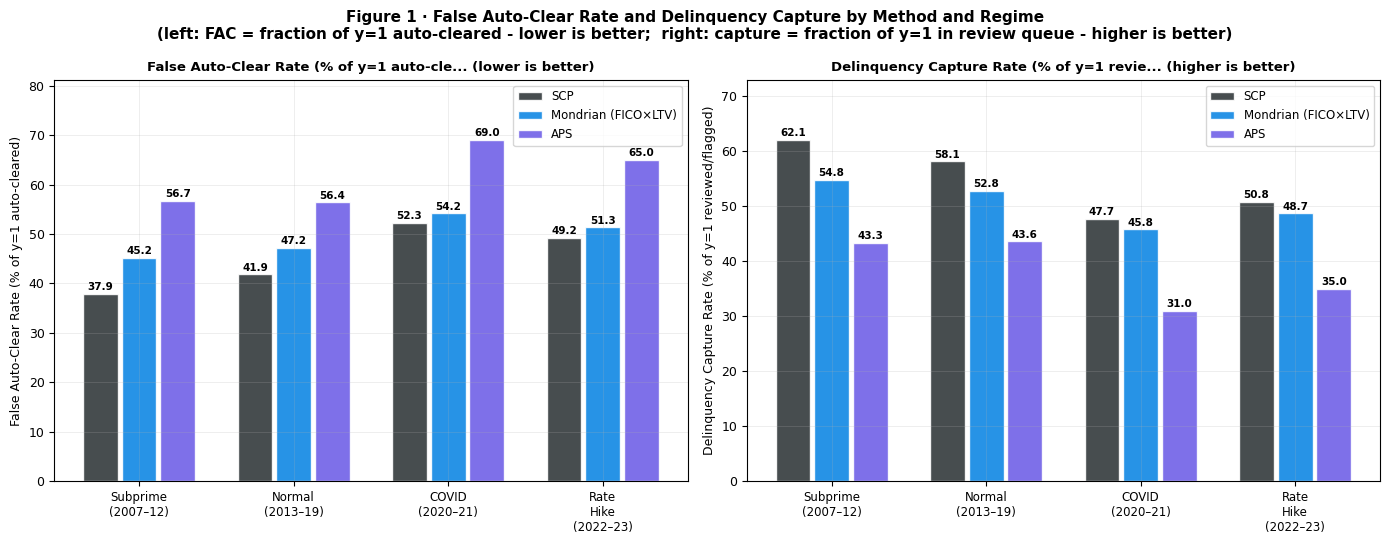

=== False Auto-Clear and Capture by method and regime ===
Method                 Regime                   FAC (%)  Capture (%)  rv_lift
----------------------------------------------------------------------------
  APS                  COVID (2020–21)           69.037        30.96    20.55x
  APS                  Normal (2013–19)          56.399        43.60    24.62x
  APS                  Rate Hike (2022–23)       65.015        34.98    34.06x
  APS                  Subprime (2007–12)        56.702        43.30    16.89x
  Mondrian (FICO×LTV)  COVID (2020–21)           54.236        45.76     8.84x
  Mondrian (FICO×LTV)  Normal (2013–19)          47.240        52.76    10.39x
  Mondrian (FICO×LTV)  Rate Hike (2022–23)       51.336        48.66    11.66x
  Mondrian (FICO×LTV)  Subprime (2007–12)        45.159        54.84     5.76x
  SCP                  COVID (2020–21)           52.309        47.69    11.09x
  SCP                  Normal (2013–19)          41.878        58.12    12.0

In [ ]:
# ── Figure 1: False auto-clear rate by method and regime ────────────────────
#
# FAC = P(auto_clear | Y=1) = fraction of future delinquents auto-cleared.
# Chow (1957, 1970) established the decision-theoretic foundations of
# reject-option systems. Here this logic is adapted to credit screening:
# a more permissive auto-clear boundary increases the share of future
# delinquent loan-months cleared automatically. FAC is an operational outcome metric here, not a
# Chow-defined quantity.

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle(
    "Figure 1 · False Auto-Clear Rate and Delinquency Capture by Method and Regime\n"
    "(left: FAC = fraction of y=1 auto-cleared - lower is better;  "
    "right: capture = fraction of y=1 in review queue - higher is better)",
    fontsize=11, fontweight="bold"
)

x    = np.arange(len(TEST_SPLITS))
w    = 0.25
xlbl = [SPLIT_LABELS[s].replace(" ", "\n") for s in TEST_SPLITS]

for ax, col, title, better in zip(
    axes,
    ["fac_pct", "capture_pct"],
    ["False Auto-Clear Rate (% of y=1 auto-cleared)",
     "Delinquency Capture Rate (% of y=1 reviewed/flagged)"],
    ["lower", "higher"]
):
    for k, method in enumerate(AUDIT_METHODS):
        vals = [rm_df[(rm_df["method"]==method)&(rm_df["split"]==s)][col].values[0]
                for s in TEST_SPLITS]
        bars = ax.bar(x + (k-1)*w, vals, w*0.9,
                      color=METHOD_COLORS[method], alpha=0.88,
                      label=METHOD_LABELS[method], edgecolor="white")
        for rect, v in zip(bars, vals):
            ax.text(rect.get_x() + rect.get_width()/2, rect.get_height() + 0.3,
                    f"{v:.1f}", ha="center", va="bottom", fontsize=7.5,
                    fontweight="bold")

    ax.set_xticks(x); ax.set_xticklabels(xlbl, fontsize=8.5)
    ax.set_ylabel(title, fontsize=9)
    ax.set_title(f"{title[:40]}... ({better} is better)", fontsize=9.5, fontweight="bold")
    ax.legend(fontsize=8.5)
    ax.grid(axis="y", alpha=0.3)
    ax.set_ylim(0, ax.get_ylim()[1] * 1.12)

fig.tight_layout()
fig.savefig(FIG_DIR / "fig1_fac_capture.png", bbox_inches="tight", dpi=FIG_DPI)
plt.show()

# Print critical numbers
print("=== False Auto-Clear and Capture by method and regime ===")
print(f"{'Method':<22} {'Regime':<22} {'FAC (%)':>9} {'Capture (%)':>12} {'rv_lift':>8}")
print("-" * 76)
for _, r in rm_df.sort_values(["method","split"]).iterrows():
    print(f"  {METHOD_LABELS[r['method']]:<20} {SPLIT_LABELS[r['split']]:<22} "
          f"{r['fac_pct']:>9.3f} {r['capture_pct']:>12.2f} {r['rv_lift']:>8.2f}x")
print("\nFigure 1 saved.")

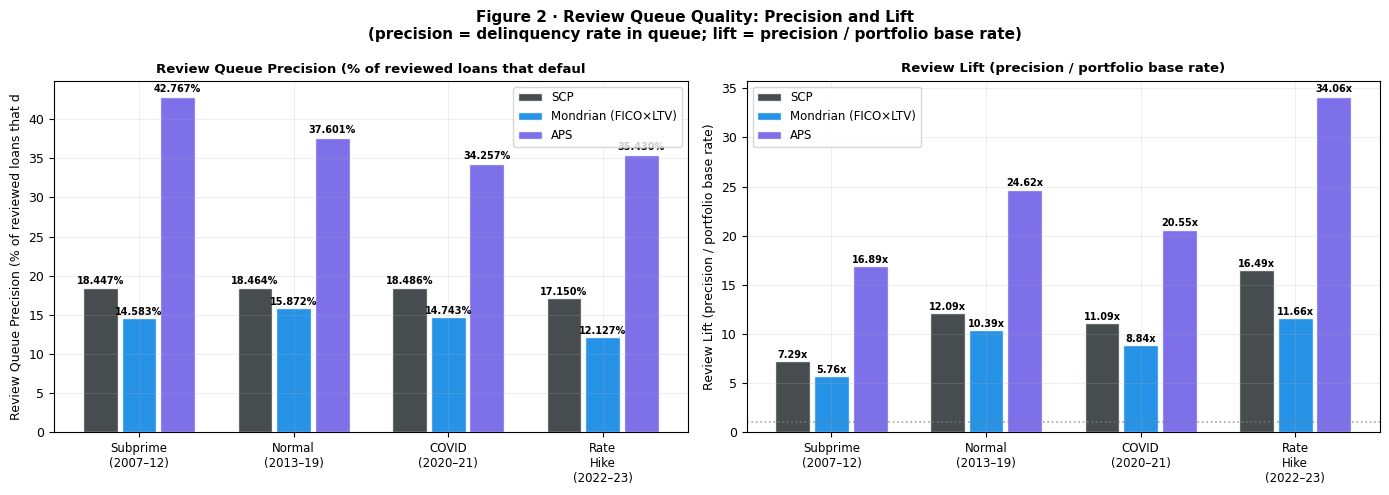


Auto-clear contamination P(y=1 | auto_clear) by method and regime:
  APS                    COVID (2020–21)        ac_contam = 1.1686%
  APS                    Normal (2013–19)       ac_contam = 0.8770%
  APS                    Rate Hike (2022–23)    ac_contam = 0.6833%
  APS                    Subprime (2007–12)     ac_contam = 1.4733%
  Mondrian (FICO×LTV)    COVID (2020–21)        ac_contam = 0.9534%
  Mondrian (FICO×LTV)    Normal (2013–19)       ac_contam = 0.7597%
  Mondrian (FICO×LTV)    Rate Hike (2022–23)    ac_contam = 0.5572%
  Mondrian (FICO×LTV)    Subprime (2007–12)     ac_contam = 1.2617%
  SCP                    COVID (2020–21)        ac_contam = 0.9113%
  SCP                    Normal (2013–19)       ac_contam = 0.6720%
  SCP                    Rate Hike (2022–23)    ac_contam = 0.5280%
  SCP                    Subprime (2007–12)     ac_contam = 1.0502%

Figure 2 saved.


In [ ]:
# ── Figure 2: Review precision and auto-clear contamination ─────────────────
#
# Review precision: of all loan-months sent to review, what fraction have Y=1?
# Review lift: how much more delinquency-dense is the review queue vs portfolio?
# Auto-clear contamination = P(y=1 | auto_clear): delinquency density in the auto-clear queue.
# Distinct from FAC = P(auto_clear | y=1): fraction of all delinquents that are auto-cleared.
#
# Review precision P(y=1 | review) characterises the review queue's quality; high review lift
# means the queue is precision-dense. Auto-clear contamination P(y=1 | auto_clear) is the
# accepted-set analogue, mapping to selective risk R_S(h,c) in Franc et al. 2023;
# the risk-coverage framing follows El-Yaniv & Wiener (2010) and Geifman & El-Yaniv (2017).

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    "Figure 2 · Review Queue Quality: Precision and Lift\n"
    "(precision = delinquency rate in queue; lift = precision / portfolio base rate)",
    fontsize=11, fontweight="bold"
)

for ax, col, title, fmt in zip(
    axes,
    ["rv_precision_pct", "rv_lift"],
    ["Review Queue Precision (% of reviewed loans that default)",
     "Review Lift (precision / portfolio base rate)"],
    ["{:.3f}%", "{:.2f}x"]
):
    for k, method in enumerate(AUDIT_METHODS):
        vals = [rm_df[(rm_df["method"]==method)&(rm_df["split"]==s)][col].values[0]
                for s in TEST_SPLITS]
        bars = ax.bar(x + (k-1)*w, vals, w*0.9,
                      color=METHOD_COLORS[method], alpha=0.88,
                      label=METHOD_LABELS[method], edgecolor="white")
        for rect, v in zip(bars, vals):
            label = fmt.format(v)
            ax.text(rect.get_x() + rect.get_width()/2, rect.get_height() + max(0.01, v*0.01),
                    label, ha="center", va="bottom", fontsize=7, fontweight="bold")

    ax.set_xticks(x); ax.set_xticklabels(xlbl, fontsize=8.5)
    ax.set_ylabel(title[:50], fontsize=9)
    ax.set_title(title[:55], fontsize=9.5, fontweight="bold")
    ax.legend(fontsize=8.5)
    ax.grid(axis="y", alpha=0.3)
    if col == "rv_lift":
        ax.axhline(1.0, color="grey", ls=":", lw=1.2, alpha=0.7, label="Portfolio baseline (lift=1)")

fig.tight_layout()
fig.savefig(FIG_DIR / "fig2_review_precision_lift.png", bbox_inches="tight", dpi=FIG_DPI)
plt.show()

# Auto-clear contamination P(y=1 | auto_clear): delinquency density inside the
# auto-clear queue, distinct from FAC = P(auto_clear | y=1).
print("\nAuto-clear contamination P(y=1 | auto_clear) by method and regime:")
for _, r in rm_df.sort_values(["method", "split"]).iterrows():
    print(f"  {METHOD_LABELS[r['method']]:<22} {SPLIT_LABELS[r['split']]:<22} "
          f"ac_contam = {r['ac_contam_pct']:.4f}%")
print("\nFigure 2 saved.")

In [ ]:
# Underlying data for Figure 2
fig2_data = (
    rm_df.loc[:, ["method", "split", "rv_precision_pct", "rv_lift"]]
    .copy()
)
fig2_data["method_label"] = fig2_data["method"].map(METHOD_LABELS)
fig2_data["split_label"] = fig2_data["split"].map(SPLIT_LABELS)
fig2_data = fig2_data[
    ["method", "method_label", "split", "split_label", "rv_precision_pct", "rv_lift"]
].sort_values(["method", "split"]).reset_index(drop=True)

print("=== Data used for Figure 2 ===")
print(fig2_data.to_string(index=False))

=== Data used for Figure 2 ===
           method        method_label          split         split_label  rv_precision_pct   rv_lift
              aps                 APS     test_covid     COVID (2020–21)         34.256650 20.547956
              aps                 APS    test_normal    Normal (2013–19)         37.600760 24.616925
              aps                 APS test_rate_hike Rate Hike (2022–23)         35.430257 34.059119
              aps                 APS  test_subprime  Subprime (2007–12)         42.766729 16.892167
mondrian_fico_ltv Mondrian (FICO×LTV)     test_covid     COVID (2020–21)         14.742538  8.842926
mondrian_fico_ltv Mondrian (FICO×LTV)    test_normal    Normal (2013–19)         15.872363 10.391512
mondrian_fico_ltv Mondrian (FICO×LTV) test_rate_hike Rate Hike (2022–23)         12.126516 11.657224
mondrian_fico_ltv Mondrian (FICO×LTV)  test_subprime  Subprime (2007–12)         14.583226  5.760139
              scp                 SCP     test_covid     COV

---
## Section 4 · Queue Contraction Translated into Delinquency Terms

SCP and Mondrian show marginal overcoverage in later regimes while their
non-auto-clear queues also contract. These patterns coincide empirically, but
queue size is determined directly by the score distribution relative to the
frozen threshold(s), not by marginal coverage itself. NB09 therefore uses
queue contraction descriptively.

This section reports:
- reviewed loan-months after scaling the 5% sample,
- captured delinquent loan-months,
- and the difference in captured delinquent loan-months relative to APS.

A smaller queue is neither inherently better nor worse. It must be interpreted jointly
with false auto-clear and capture.

### Connection to the matched-budget comparison

At a fixed non-auto-clear budget, SCP and deterministic APS select exactly the
same upper-tail loan-months as the calibrated-probability ranking, so
$\Delta = 0$ structurally. Mondrian's cell-specific thresholds reorder the
portfolio and produce $\Delta < 0$.

In [ ]:
# ── Section 4: Queue contraction in delinquency terms ─────────────────────
#
# Scale factor: sample is 5% of full dataset.

SCALE = 1 / SAMPLE_FRAC   # 20× to extrapolate from 5% sample

_cp_manifest_rc = CP_MANIFEST.get("row_counts", {})
FULL_N = {}
for _spl in TEST_SPLITS:
    if _spl in _cp_manifest_rc:
        FULL_N[_spl] = int(_cp_manifest_rc[_spl])
    else:
        # Derive from loaded 5% sample
        _n_sample = len(split_dfs[_spl])
        FULL_N[_spl] = round(_n_sample / SAMPLE_FRAC)
        print(f"row_counts for {_spl} not in cp_manifest; "
              f"estimated from sample: {_n_sample:,} / {SAMPLE_FRAC:.0%} → {FULL_N[_spl]:,}")
print("Full-dataset row counts (used for extrapolation):")
for _spl, _n in FULL_N.items():
    print(f"  {SPLIT_LABELS[_spl]}: {_n:,}")

print("=" * 95)
print(f"{'Regime':<22} {'Method':<22} {'ReviewRate':>11} {'ReviewedLoans':>14} {'y=1 Captured':>13} {'Miss vs APS':>12}")
print("=" * 95)

contraction_rows = []
for split in TEST_SPLITS:
    n_full      = FULL_N[split]
    # APS baseline for this regime
    aps_row     = rm_df[(rm_df["method"]=="aps")&(rm_df["split"]==split)].iloc[0]
    aps_y1_cap  = aps_row["n_y1_rv"] + aps_row["n_y1_hr"]  # sample count

    for method in AUDIT_METHODS:
        mrow     = rm_df[(rm_df["method"]==method)&(rm_df["split"]==split)].iloc[0]
        y1_cap   = mrow["n_y1_rv"] + mrow["n_y1_hr"]       # in 5% sample
        y1_miss  = aps_y1_cap - y1_cap                      # extra y=1 missed vs APS (sample)
        y1_miss_full = y1_miss * SCALE                       # extrapolated to full dataset

        # Extrapolated full-dataset review volumes
        rv_loans_full = mrow["rv_rate_pct"] / 100 * n_full
        y1_cap_full   = y1_cap * SCALE

        print(f"  {SPLIT_LABELS[split]:<20} {METHOD_LABELS[method]:<22} "
              f"{mrow['rv_rate_pct']:>10.2f}% "
              f"{rv_loans_full/1e6:>11.2f}M "
              f"{y1_cap_full/1e6:>10.3f}M "
              f"{y1_miss_full/1e3:>+11.1f}K")

        contraction_rows.append({
            "split"       : split, "mechanism": SPLIT_MECH[split],
            "method"      : method,
            "rv_rate_pct" : mrow["rv_rate_pct"],
            "rv_loans_M"  : rv_loans_full / 1e6,
            "y1_captured_M": y1_cap_full / 1e6,
            "y1_miss_vs_aps_K": y1_miss_full / 1e3,
        })

contraction_df = pd.DataFrame(contraction_rows)
contraction_df.to_csv(NB09_OUT_DIR / "nb09_queue_contraction.csv", index=False)
print("=" * 95)
print("Positive: y=1 loans missed RELATIVE to APS; negative: method captures MORE y=1 than APS")

Full-dataset row counts (used for extrapolation):
  Subprime (2007–12): 633,244,002
  Normal (2013–19): 753,732,904
  COVID (2020–21): 201,447,058
  Rate Hike (2022–23): 306,340,880
Regime                 Method                  ReviewRate  ReviewedLoans  y=1 Captured  Miss vs APS
  Subprime (2007–12)   SCP                          8.52%       53.93M      9.958M     -3009.4K
  Subprime (2007–12)   Mondrian (FICO×LTV)          9.35%       59.22M      8.801M     -1852.5K
  Subprime (2007–12)   APS                          2.56%       16.23M      6.948M        +0.0K
  Normal (2013–19)     SCP                          4.81%       36.24M      6.709M     -1676.2K
  Normal (2013–19)     Mondrian (FICO×LTV)          5.00%       37.67M      6.090M     -1057.3K
  Normal (2013–19)     APS                          1.77%       13.35M      5.033M        +0.0K
  COVID (2020–21)      SCP                          4.30%        8.66M      1.603M      -562.2K
  COVID (2020–21)      Mondrian (FICO×LTV)    

---
## Section 5 · Review-Budget Curves (Figure 3)

The review-budget curve asks: at a fixed budget of k% of loan-months not
auto-cleared, how many future delinquencies are captured?

This is the credit-risk analogue of the **risk-coverage curve** in selective
classification (El-Yaniv & Wiener, 2010; Geifman & El-Yaniv, 2017; Franc et al., 2023),
adapted to the review-queue operational context. It evaluates performance
across a *range* of operating points rather than at a single threshold.

### Non-CP probability-ranking baseline

The baseline ranks all loan-months by descending calibrated estimated
delinquency probability `p̂_cal` and selects the top `k%` at the same
non-auto-clear budget. It is a probability-ranking benchmark, not a claim that
`p̂_cal` equals the true posterior probability.

Classical reject-option theory is related but distinct: it derives abstention
rules from posterior uncertainty (Chow, 1957, 1970; Herbei & Wegkamp, 2006),
whereas NB09 uses the fitted calibrated score as a matched-budget ranking baseline.

The comparison between CP methods and this baseline answers the central operational
question of this part of the thesis:

> **Does conformal routing add selection value beyond the calibrated risk ranking
> at a matched non-auto-clear budget?**

If the CP natural operating point lies on the probability-threshold curve, CP and
p̂_cal thresholding are operationally equivalent at that budget.
If CP lies above, CP adds selection value.
If CP lies below, the probability threshold is superior.

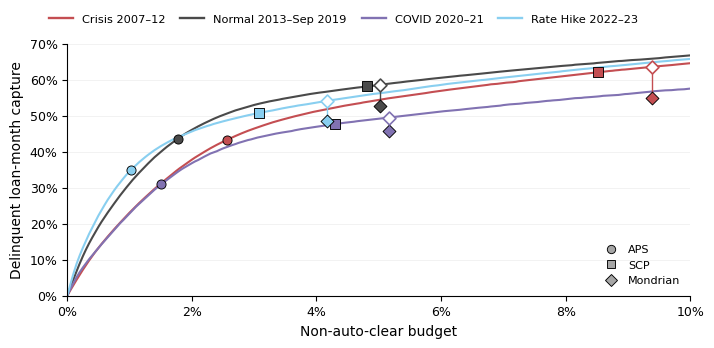

Figure 5.4 operating-point checks:
         split            method budget_pct cp_capture_pct baseline_capture_pct delta_pp  boundary_tie  boundary_tie_n
    test_covid               aps       1.51          30.96                30.96   +0.000         False               0
    test_covid mondrian_fico_ltv       5.16          45.76                49.50   -3.732          True           40117
    test_covid               scp       4.30          47.69                47.69   +0.000         False               0
   test_normal               aps       1.77          43.60                43.60   +0.000         False               0
   test_normal mondrian_fico_ltv       5.02          52.76                58.58   -5.818          True           94820
   test_normal               scp       4.81          58.12                58.12   +0.000         False               0
test_rate_hike               aps       1.03          34.98                34.98   +0.000         False               0
test_rate_hik

In [ ]:
# ── Thesis Figure 4.4: Capture against non-auto-clear budget ────────────────
import gc
from matplotlib.lines import Line2D

FIG54_MAX_BUDGET_PCT = 10.0
FIG54_GRID = np.linspace(0.0, FIG54_MAX_BUDGET_PCT, 201)

# Thesis-facing regime labels.
FIG54_SPLIT_LABELS = {
    "test_subprime":  "Crisis 2007–12",
    "test_normal":    "Normal 2013–Sep 2019",
    "test_covid":     "COVID 2020–21",
    "test_rate_hike": "Rate Hike 2022–23",
}

FIG54_SPLIT_COLORS = {
    "test_subprime":  "#C44E52",
    "test_normal":    "#4A4A4A",
    "test_covid":     "#8172B2",
    "test_rate_hike": "#89CFF0",
}

# Method is encoded by marker shape; regime is encoded by colour.
FIG54_METHOD_MARKERS = {
    "aps": "o",
    "scp": "s",
    "mondrian_fico_ltv": "D",
}

# Locked NB09 / Appendix G.4 values.
# Fail if a rerun changes any result at the precision reported in the thesis.
FIG54_EXPECTED = {
    ("test_subprime", "scp"):
        (8.52, 62.05, 62.05, +0.000),
    ("test_subprime", "mondrian_fico_ltv"):
        (9.38, 54.84, 63.58, -8.739),
    ("test_subprime", "aps"):
        (2.56, 43.30, 43.30, +0.000),

    ("test_normal", "scp"):
        (4.81, 58.12, 58.12, +0.000),
    ("test_normal", "mondrian_fico_ltv"):
        (5.02, 52.76, 58.58, -5.818),
    ("test_normal", "aps"):
        (1.77, 43.60, 43.60, +0.000),

    ("test_covid", "scp"):
        (4.30, 47.69, 47.69, +0.000),
    ("test_covid", "mondrian_fico_ltv"):
        (5.16, 45.76, 49.50, -3.732),
    ("test_covid", "aps"):
        (1.51, 30.96, 30.96, +0.000),

    ("test_rate_hike", "scp"):
        (3.08, 50.81, 50.81, +0.000),
    ("test_rate_hike", "mondrian_fico_ltv"):
        (4.17, 48.66, 54.09, -5.426),
    ("test_rate_hike", "aps"):
        (1.03, 34.98, 34.98, +0.000),
}

frontier_rows = []
point_rows = []

for split in TEST_SPLITS:

    # Only retain columns required for this diagnostic.
    cols = ["y", "p_hat_cal", *ROUTE_COLS.values()]
    sub = df_pd.loc[df_pd["split"].eq(split), cols]

    y = sub["y"].to_numpy(dtype=np.int8, copy=False)
    p_hat = sub["p_hat_cal"].to_numpy(dtype=np.float32, copy=False)

    n = len(sub)
    n_y1 = int(y.sum())

    assert n > 0 and n_y1 > 0, f"{split}: empty split or no positives"
    assert np.isfinite(p_hat).all(), f"{split}: non-finite p_hat_cal"

    # Preserve the original NB09 ranking convention explicitly.
    #
    # Quicksort is specified because np.argsort() used that default in the
    # original NB09 implementation. The boundary-tie diagnostic below records
    # whether a matched Mondrian budget cuts through an isotonic score tie.
    order = np.argsort(-p_hat, kind="quicksort")

    y_sorted = y[order]
    cumcap = np.cumsum(y_sorted, dtype=np.int64)

    split_points = []

    # -----------------------------------------------------------------------
    # Natural operating points and exact matched-budget comparison
    # -----------------------------------------------------------------------

    for method, rcol in ROUTE_COLS.items():

        route = sub[rcol].to_numpy(copy=False)

        # Budget = everything not auto-cleared:
        # review + high_risk/escalation.
        budget_mask = route != "auto_clear"

        # Use the exact number of selected rows.
        # Do not reconstruct k from a floating-point percentage.
        budget_n = int(np.count_nonzero(budget_mask))
        budget_pct = budget_n / n * 100.0

        cp_y1_n = int(y[budget_mask].sum())
        cp_capture_pct = cp_y1_n / n_y1 * 100.0

        if budget_n == 0:
            baseline_y1_n = 0
            baseline_capture_pct = 0.0
            cutoff_score = np.nan
            boundary_tie = False
            boundary_tie_n = 0

        else:
            # Probability-ranking baseline at exactly the same row budget.
            baseline_y1_n = int(cumcap[budget_n - 1])
            baseline_capture_pct = baseline_y1_n / n_y1 * 100.0

            cutoff_score = float(p_hat[order[budget_n - 1]])

            # Diagnostic only: does the top-k boundary split an isotonic tie?
            boundary_tie = bool(
                budget_n < n
                and p_hat[order[budget_n - 1]]
                == p_hat[order[budget_n]]
            )

            boundary_tie_n = (
                int(np.count_nonzero(
                    p_hat == np.float32(cutoff_score)
                ))
                if boundary_tie
                else 0
            )

        delta_pp = cp_capture_pct - baseline_capture_pct

        row = {
            "split": split,
            "method": method,
            "budget_n": budget_n,
            "budget_pct": budget_pct,
            "cp_capture_pct": cp_capture_pct,
            "baseline_capture_pct": baseline_capture_pct,
            "delta_pp": delta_pp,
            "baseline_cutoff_score": cutoff_score,
            "boundary_tie": boundary_tie,
            "boundary_tie_n": boundary_tie_n,
        }

        point_rows.append(row)
        split_points.append(row)

    # -----------------------------------------------------------------------
    # Probability-ranking frontier
    # -----------------------------------------------------------------------
    #
    # Use the regular 0–10% grid, but explicitly insert each method's exact
    # natural row budget. Therefore every SCP/APS point and every hollow
    # Mondrian baseline point is an exact stored point on the curve rather
    # than an interpolation between grid values.

    grid_n = np.floor(
        FIG54_GRID / 100.0 * n
    ).astype(np.int64)

    exact_n = np.array(
        [r["budget_n"] for r in split_points],
        dtype=np.int64,
    )

    curve_n = np.unique(
        np.concatenate([grid_n, exact_n])
    )

    curve_n = curve_n[
        (curve_n >= 0) & (curve_n <= n)
    ]

    curve_capture = np.zeros(
        len(curve_n),
        dtype=float,
    )

    positive_budget = curve_n > 0

    curve_capture[positive_budget] = (
        cumcap[curve_n[positive_budget] - 1]
        / n_y1
        * 100.0
    )

    for k, cap in zip(curve_n, curve_capture):
        frontier_rows.append({
            "split": split,
            "budget_n": int(k),
            "budget_pct": float(k / n * 100.0),
            "baseline_capture_pct": float(cap),
        })

    del sub, y, p_hat, order, y_sorted, cumcap
    gc.collect()


# ---------------------------------------------------------------------------
# Persist exact figure data
# ---------------------------------------------------------------------------

fig54_frontier_df = (
    pd.DataFrame(frontier_rows)
    .sort_values(["split", "budget_n"])
    .reset_index(drop=True)
)

fig54_points_df = (
    pd.DataFrame(point_rows)
    .sort_values(["split", "method"])
    .reset_index(drop=True)
)


# ---------------------------------------------------------------------------
# Structural checks
# ---------------------------------------------------------------------------

assert (
    len(fig54_points_df)
    == len(TEST_SPLITS) * len(AUDIT_METHODS)
    == 12
)

# Every natural operating point must lie inside the displayed budget range.
assert (
    fig54_points_df["budget_pct"].max()
    <= FIG54_MAX_BUDGET_PCT
)

# Every probability frontier must begin at the origin and be non-decreasing.
for split in TEST_SPLITS:

    f = fig54_frontier_df[
        fig54_frontier_df["split"].eq(split)
    ]

    assert f.iloc[0]["budget_n"] == 0
    assert f.iloc[0]["baseline_capture_pct"] == 0.0

    assert np.all(
        np.diff(
            f["baseline_capture_pct"].to_numpy()
        ) >= -1e-12
    )


# ---------------------------------------------------------------------------
# Locked thesis-result checks
# ---------------------------------------------------------------------------

for (split, method), expected in FIG54_EXPECTED.items():

    r = fig54_points_df[
        fig54_points_df["split"].eq(split)
        & fig54_points_df["method"].eq(method)
    ].iloc[0]

    exp_budget, exp_cp, exp_bl, exp_delta = expected

    assert (
        f"{r['budget_pct']:.2f}"
        == f"{exp_budget:.2f}"
    ), (split, method, "budget")

    assert (
        f"{r['cp_capture_pct']:.2f}"
        == f"{exp_cp:.2f}"
    ), (split, method, "CP capture")

    assert (
        f"{r['baseline_capture_pct']:.2f}"
        == f"{exp_bl:.2f}"
    ), (split, method, "baseline capture")

    assert (
        f"{r['delta_pp']:+.3f}"
        == f"{exp_delta:+.3f}"
    ), (split, method, "delta")


# SCP and deterministic APS are global score-threshold rules and therefore
# must select the same upper-tail rows as the probability-ranking baseline.
for method in ["scp", "aps"]:

    g = fig54_points_df[
        fig54_points_df["method"].eq(method)
    ]

    assert (~g["boundary_tie"]).all()

    assert np.all(
        np.abs(
            g["delta_pp"].to_numpy()
        ) < 1e-12
    )


# Mondrian must remain below the global probability ranking in all regimes.
mond = fig54_points_df[
    fig54_points_df["method"].eq(
        "mondrian_fico_ltv"
    )
]

assert (mond["delta_pp"] < 0).all()


# ---------------------------------------------------------------------------
# Save source data
# ---------------------------------------------------------------------------

frontier_path = (
    NB09_OUT_DIR
    / "nb09_capture_frontier.csv"
)

points_path = (
    NB09_OUT_DIR
    / "nb09_capture_operating_points.csv"
)

fig54_frontier_df.to_csv(
    frontier_path,
    index=False,
)

fig54_points_df.to_csv(
    points_path,
    index=False,
)


# ---------------------------------------------------------------------------
# Plot
# ---------------------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(7.0, 4)
)


# One probability-ranking frontier per regime.
for split in TEST_SPLITS:

    f = fig54_frontier_df[
        fig54_frontier_df["split"].eq(split)
    ]

    ax.plot(
        f["budget_pct"],
        f["baseline_capture_pct"],
        color=FIG54_SPLIT_COLORS[split],
        linewidth=1.5,
        zorder=2,
    )


# Natural conformal operating points.
for _, r in fig54_points_df.iterrows():

    split = r["split"]
    method = r["method"]
    color = FIG54_SPLIT_COLORS[split]

    # Actual conformal operating point.
    ax.scatter(
        r["budget_pct"],
        r["cp_capture_pct"],
        s=43,
        marker=FIG54_METHOD_MARKERS[method],
        facecolor=color,
        edgecolor="black",
        linewidth=0.65,
        zorder=5,
    )

    # Mondrian alone gets an explicit matched-budget comparison:
    # filled diamond = Mondrian;
    # hollow diamond = probability ranking at the same budget.
    if method == "mondrian_fico_ltv":

        ax.vlines(
            r["budget_pct"],
            r["cp_capture_pct"],
            r["baseline_capture_pct"],
            color=color,
            linewidth=1.0,
            zorder=3,
        )

        ax.scatter(
            r["budget_pct"],
            r["baseline_capture_pct"],
            s=43,
            marker="D",
            facecolor="white",
            edgecolor=color,
            linewidth=1.2,
            zorder=6,
        )


# Dynamic upper limit from the actual 0–10% frontiers.
max_capture = max(
    fig54_frontier_df[
        "baseline_capture_pct"
    ].max(),
    fig54_points_df[
        "baseline_capture_pct"
    ].max(),
    fig54_points_df[
        "cp_capture_pct"
    ].max(),
)

y_upper = min(
    100.0,
    max(
        60.0,
        np.ceil(
            (max_capture + 2.0) / 10.0
        ) * 10.0,
    ),
)


ax.set_xlim(
    0,
    FIG54_MAX_BUDGET_PCT,
)

ax.set_ylim(
    0,
    y_upper,
)

ax.set_xticks(
    np.arange(
        0,
        FIG54_MAX_BUDGET_PCT + 0.1,
        2.0,
    )
)

ax.set_yticks(
    np.arange(
        0,
        y_upper + 0.1,
        10.0,
    )
)

ax.xaxis.set_major_formatter(
    mpl.ticker.PercentFormatter(
        xmax=100,
        decimals=0,
    )
)

ax.yaxis.set_major_formatter(
    mpl.ticker.PercentFormatter(
        xmax=100,
        decimals=0,
    )
)

ax.set_xlabel(
    "Non-auto-clear budget"
)

ax.set_ylabel(
    "Delinquent loan-month capture"
)

ax.grid(False)

ax.grid(
    axis="y",
    alpha=0.18,
    linewidth=0.6,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


# Regime = colour.
regime_handles = [
    Line2D(
        [0], [0],
        color=FIG54_SPLIT_COLORS[s],
        lw=1.7,
        label=FIG54_SPLIT_LABELS[s],
    )
    for s in TEST_SPLITS
]

fig.legend(
    handles=regime_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.920),
    ncol=4,
    frameon=False,
    fontsize=8.2,
    handlelength=2.1,
    columnspacing=1.3,
)

# Method = marker.
method_order = [
    "aps",
    "scp",
    "mondrian_fico_ltv",
]

method_handles = [
    Line2D(
        [0],
        [0],
        marker=FIG54_METHOD_MARKERS[m],
        linestyle="None",
        markerfacecolor="0.65",
        markeredgecolor="black",
        markeredgewidth=0.65,
        markersize=6,
        label=(
            "Mondrian"
            if m == "mondrian_fico_ltv"
            else METHOD_LABELS[m]
        ),
    )
    for m in method_order
]

ax.legend(
    handles=method_handles,
    loc="lower right",
    frameon=False,
    fontsize=8.0,
    handletextpad=0.5,
)


fig.subplots_adjust(
    left=0.105,
    right=0.995,
    bottom=0.19,
    top=0.82,
)


fig54_path = (
    FIG_DIR
    / "fig5_4_capture_budget_frontier.png"
)

fig54_pdf_path = fig54_path.with_suffix(".pdf")

# Raster copy for notebook / quick inspection
fig.savefig(
    fig54_path,
    bbox_inches="tight",
    dpi=FIG_DPI,
)

# Vector copy for the thesis
fig.savefig(
    fig54_pdf_path,
    bbox_inches="tight",
)

plt.show()


# ---------------------------------------------------------------------------
# Compact audit output
# ---------------------------------------------------------------------------

print("Figure 5.4 operating-point checks:")

print(
    fig54_points_df[
        [
            "split",
            "method",
            "budget_pct",
            "cp_capture_pct",
            "baseline_capture_pct",
            "delta_pp",
            "boundary_tie",
            "boundary_tie_n",
        ]
    ].to_string(
        index=False,
        formatters={
            "budget_pct":
                lambda x: f"{x:.2f}",
            "cp_capture_pct":
                lambda x: f"{x:.2f}",
            "baseline_capture_pct":
                lambda x: f"{x:.2f}",
            "delta_pp":
                lambda x: f"{x:+.3f}",
        },
    )
)

print(f"\nFrontier data : {frontier_path}")
print(f"Operating pts : {points_path}")
print(f"Figure        : {fig54_path}")
print(f"Figure PDF    : {fig54_pdf_path}")

In [ ]:
# ── Figure 5.4 diagnostic: Mondrian matched-budget tie sensitivity ──────────
#
# Purpose:
# At each Mondrian natural budget, determine the exact range of capture that
# the global p_hat_cal ranking can attain over ALL admissible orderings within
# the isotonic tie block at the budget boundary.
#
# If Mondrian capture is below the minimum attainable probability-baseline
# capture, its negative equal-budget gap is invariant to tie-breaking.

import gc

TIE_METHOD = "mondrian_fico_ltv"

required_point_cols = {
    "split",
    "method",
    "budget_n",
    "budget_pct",
    "cp_capture_pct",
    "baseline_capture_pct",
    "baseline_cutoff_score",
    "boundary_tie",
    "boundary_tie_n",
}

assert required_point_cols.issubset(fig54_points_df.columns)
assert TIE_METHOD in ROUTE_COLS

tie_rows = []

for split in TEST_SPLITS:

    # Exact Mondrian operating point already computed in Figure 5.4.
    point = fig54_points_df[
        fig54_points_df["split"].eq(split)
        & fig54_points_df["method"].eq(TIE_METHOD)
    ]

    assert len(point) == 1
    point = point.iloc[0]

    budget_n = int(point["budget_n"])
    cutoff = np.float32(point["baseline_cutoff_score"])

    # Work only with the columns required for this diagnostic.
    sub = df_pd.loc[
        df_pd["split"].eq(split),
        ["y", "p_hat_cal", ROUTE_COLS[TIE_METHOD]],
    ]

    y = sub["y"].to_numpy(dtype=np.int8, copy=False)
    p = sub["p_hat_cal"].to_numpy(dtype=np.float32, copy=False)
    route = sub[ROUTE_COLS[TIE_METHOD]].to_numpy(copy=False)

    n = len(sub)
    n_y1 = int(y.sum())

    assert n > 0
    assert n_y1 > 0
    assert 0 < budget_n < n

    # -----------------------------------------------------------------------
    # Decompose the matched top-k probability ranking:
    #
    #   p > cutoff       : selected under every admissible tie-breaking
    #   p = cutoff       : boundary tie block
    #   m_from_tie       : number that must be selected from that tie block
    # -----------------------------------------------------------------------

    gt_mask = p > cutoff
    eq_mask = p == cutoff

    n_gt = int(np.count_nonzero(gt_mask))
    n_eq = int(np.count_nonzero(eq_mask))

    y_gt = int(y[gt_mask].sum())
    y_eq = int(y[eq_mask].sum())

    m_from_tie = budget_n - n_gt

    assert n_eq > 0
    assert 0 < m_from_tie <= n_eq
    assert n_gt + m_from_tie == budget_n

    # The Figure 5.4 diagnostic said the Mondrian cutoff is inside a tie.
    boundary_tie = m_from_tie < n_eq

    assert boundary_tie == bool(point["boundary_tie"])
    assert n_eq == int(point["boundary_tie_n"])

    # -----------------------------------------------------------------------
    # Exact extremal positive counts inside the boundary tie.
    #
    # Minimum:
    #   select negatives from the tie first.
    #
    # Maximum:
    #   select positives from the tie first.
    #
    # Expected:
    #   uniform random selection of m_from_tie observations from the tie.
    # -----------------------------------------------------------------------

    n_eq_neg = n_eq - y_eq

    tie_pos_min = max(
        0,
        m_from_tie - n_eq_neg,
    )

    tie_pos_max = min(
        m_from_tie,
        y_eq,
    )

    tie_pos_expected = (
        m_from_tie * y_eq / n_eq
    )

    baseline_y1_min = y_gt + tie_pos_min
    baseline_y1_max = y_gt + tie_pos_max
    baseline_y1_expected = y_gt + tie_pos_expected

    baseline_capture_min = (
        baseline_y1_min / n_y1 * 100.0
    )

    baseline_capture_max = (
        baseline_y1_max / n_y1 * 100.0
    )

    baseline_capture_expected = (
        baseline_y1_expected / n_y1 * 100.0
    )

    # -----------------------------------------------------------------------
    # Exact Mondrian capture at its natural non-auto-clear budget.
    # -----------------------------------------------------------------------

    mondrian_mask = route != "auto_clear"

    assert int(np.count_nonzero(mondrian_mask)) == budget_n

    mondrian_y1_n = int(y[mondrian_mask].sum())

    mondrian_capture = (
        mondrian_y1_n / n_y1 * 100.0
    )

    assert (
        f"{mondrian_capture:.2f}"
        == f"{point['cp_capture_pct']:.2f}"
    )

    # Historical deterministic quicksort baseline from Figure 5.4.
    deterministic_baseline = float(
        point["baseline_capture_pct"]
    )

    assert (
        baseline_capture_min - 1e-12
        <= deterministic_baseline
        <= baseline_capture_max + 1e-12
    )

    # -----------------------------------------------------------------------
    # Tie-robust gaps.
    #
    # delta_vs_min is the MOST FAVOURABLE admissible comparison for Mondrian.
    # If it is still negative, Mondrian loses under every possible ordering
    # of the tied p_hat_cal observations.
    # -----------------------------------------------------------------------

    delta_vs_min = (
        mondrian_capture
        - baseline_capture_min
    )

    delta_vs_expected = (
        mondrian_capture
        - baseline_capture_expected
    )

    delta_vs_max = (
        mondrian_capture
        - baseline_capture_max
    )

    robust_underperformance = (
        delta_vs_min < -1e-12
    )

    # Fraction of the boundary tie that the matched budget must retain.
    tie_selected_pct = (
        m_from_tie / n_eq * 100.0
    )

    tie_positive_rate_pct = (
        y_eq / n_eq * 100.0
    )

    tie_rows.append({
        "split": split,

        "budget_n": budget_n,
        "budget_pct": float(point["budget_pct"]),

        "cutoff_score": float(cutoff),

        "n_gt_cutoff": n_gt,
        "y1_gt_cutoff": y_gt,

        "tie_n": n_eq,
        "tie_y1": y_eq,
        "tie_positive_rate_pct": tie_positive_rate_pct,

        "selected_from_tie_n": m_from_tie,
        "selected_from_tie_pct": tie_selected_pct,

        "mondrian_capture_pct": mondrian_capture,

        "baseline_capture_min_pct": baseline_capture_min,
        "baseline_capture_expected_pct": baseline_capture_expected,
        "baseline_capture_max_pct": baseline_capture_max,

        "baseline_capture_deterministic_pct":
            deterministic_baseline,

        "delta_vs_min_baseline_pp": delta_vs_min,
        "delta_vs_expected_baseline_pp": delta_vs_expected,
        "delta_vs_max_baseline_pp": delta_vs_max,

        "robust_underperformance":
            robust_underperformance,
    })

    del (
        sub,
        y,
        p,
        route,
        gt_mask,
        eq_mask,
        mondrian_mask,
    )
    gc.collect()


# ---------------------------------------------------------------------------
# Result table
# ---------------------------------------------------------------------------

fig54_tie_df = (
    pd.DataFrame(tie_rows)
    .set_index("split")
    .loc[TEST_SPLITS]
    .reset_index()
)

# Basic mathematical consistency checks.
assert (
    fig54_tie_df[
        "baseline_capture_min_pct"
    ]
    <= fig54_tie_df[
        "baseline_capture_expected_pct"
    ]
).all()

assert (
    fig54_tie_df[
        "baseline_capture_expected_pct"
    ]
    <= fig54_tie_df[
        "baseline_capture_max_pct"
    ]
).all()

assert (
    fig54_tie_df[
        "baseline_capture_min_pct"
    ]
    <= fig54_tie_df[
        "baseline_capture_deterministic_pct"
    ] + 1e-12
).all()

assert (
    fig54_tie_df[
        "baseline_capture_deterministic_pct"
    ]
    <= fig54_tie_df[
        "baseline_capture_max_pct"
    ] + 1e-12
).all()


# ---------------------------------------------------------------------------
# Save diagnostic
# ---------------------------------------------------------------------------

tie_path = (
    NB09_OUT_DIR
    / "nb09_mondrian_tie_sensitivity.csv"
)

fig54_tie_df.to_csv(
    tie_path,
    index=False,
)


# ---------------------------------------------------------------------------
# Compact audit output
# ---------------------------------------------------------------------------

print(
    "Mondrian matched-budget tie sensitivity\n"
    "========================================"
)

display_cols = [
    "split",
    "budget_pct",
    "tie_n",
    "tie_y1",
    "selected_from_tie_n",
    "mondrian_capture_pct",
    "baseline_capture_min_pct",
    "baseline_capture_expected_pct",
    "baseline_capture_max_pct",
    "delta_vs_min_baseline_pp",
    "delta_vs_expected_baseline_pp",
    "delta_vs_max_baseline_pp",
    "robust_underperformance",
]

print(
    fig54_tie_df[
        display_cols
    ].to_string(
        index=False,
        formatters={
            "budget_pct":
                lambda x: f"{x:.2f}",
            "mondrian_capture_pct":
                lambda x: f"{x:.3f}",
            "baseline_capture_min_pct":
                lambda x: f"{x:.3f}",
            "baseline_capture_expected_pct":
                lambda x: f"{x:.3f}",
            "baseline_capture_max_pct":
                lambda x: f"{x:.3f}",
            "delta_vs_min_baseline_pp":
                lambda x: f"{x:+.3f}",
            "delta_vs_expected_baseline_pp":
                lambda x: f"{x:+.3f}",
            "delta_vs_max_baseline_pp":
                lambda x: f"{x:+.3f}",
        },
    )
)

print(
    "\nTie-robust underperformance in all regimes:",
    bool(
        fig54_tie_df[
            "robust_underperformance"
        ].all()
    ),
)

print(
    "\nSaved:",
    tie_path,
)

Mondrian matched-budget tie sensitivity
         split budget_pct  tie_n  tie_y1  selected_from_tie_n mondrian_capture_pct baseline_capture_min_pct baseline_capture_expected_pct baseline_capture_max_pct delta_vs_min_baseline_pp delta_vs_expected_baseline_pp delta_vs_max_baseline_pp  robust_underperformance
 test_subprime       9.38 144367    6216               132910               54.841                   62.863                        63.576                   63.638                   -8.022                        -8.735                   -8.796                     True
   test_normal       5.02  94820    3209                78326               52.760                   58.122                        58.581                   58.678                   -5.361                        -5.821                   -5.917                     True
    test_covid       5.16  40117    1345                 7391               45.764                   49.361                        49.508                   

---
## Section 6 · Matched Non-Auto-Clear Budget Comparison (Figure 4)

The review-budget curves show the full frontier. Here the question is:

> **At the same non-auto-clear budget, does conformal routing capture more future
> delinquent loan-months than the calibrated-probability ranking?**

For each method and regime I compare:

1. conformal capture at the method's natural non-auto-clear budget;
2. baseline capture at the same row budget using descending `p̂_cal`.

Holding the row budget fixed isolates differences in selection ordering.

### Interpreting the matched non-auto-clear-budget comparison

This comparison comes with an important structural caveat that governs how the
Δ column should be read.

For SCP and APS, the non-auto-clear region is exactly a one-sided threshold on
`p_hat_cal`: SCP uses `{p_hat_cal > q_SCP}` and APS uses
`{p_hat_cal >= 1 - q_APS}`. This identity does not depend on how the
non-auto-clear tail splits between review and escalation.

At each method's natural non-auto-clear budget, that threshold selects the same
upper-tail rows as the probability baseline at the exact same row count. The
consequence is that **Δ = 0 for SCP and APS is an algebraic identity, not an
empirical result**: a CP method that routes on a global threshold of the
calibrated score lies, by construction, exactly on the baseline's
capture-vs-budget curve and can neither beat nor lag it.

The informative quantity is therefore the **Mondrian Δ < 0**. Its cell-specific
thresholds break the global `p_hat_cal` ordering, so at the same non-auto-clear
budget the selected set captures fewer delinquent loan-months. The −3.7 to
−8.7 pp range is the measured selection-efficiency deficit associated here with
the same cell-wise construction that narrows subgroup coverage disparities in
NB06–NB08.

For SCP and deterministic APS, the conformal layer therefore adds no capture
lift over the calibrated-score ranking at a matched budget. Any remaining value
must be assessed on other dimensions, such as set-valued routing semantics or
subgroup reliability auditing.

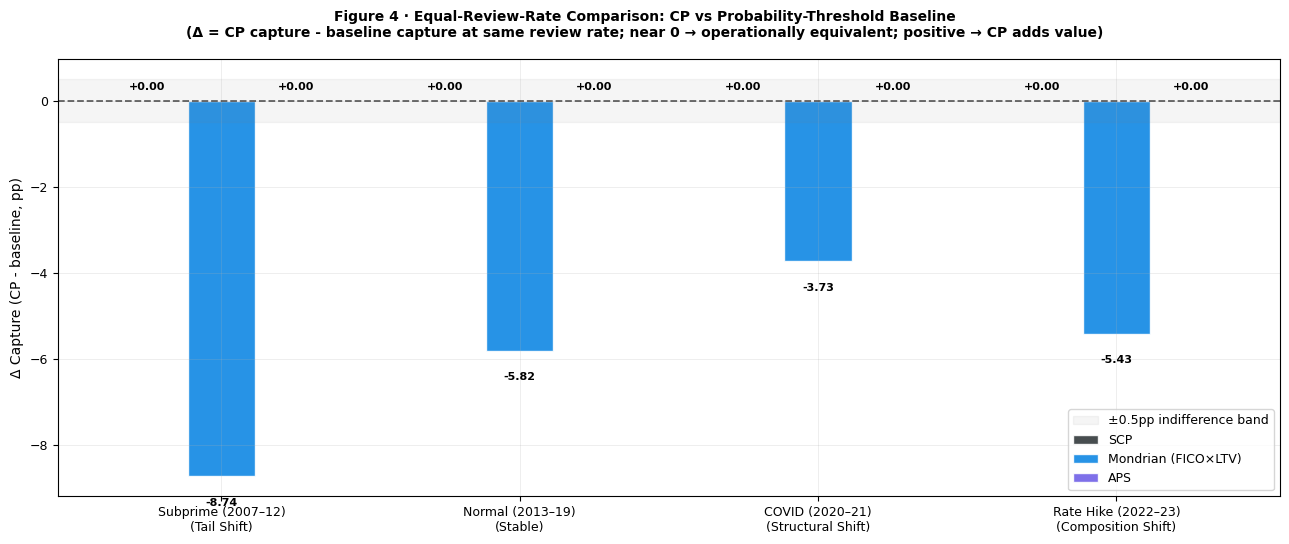

=== Equal-Review-Rate Comparison ===
Method                 Regime                  RV Rate  CP Cap%  BL Cap%   Δ (pp)
--------------------------------------------------------------------------------
  SCP                  Subprime (2007–12)        8.52%    62.05    62.05   +0.000
  Mondrian (FICO×LTV)  Subprime (2007–12)        9.38%    54.84    63.58   -8.739
  APS                  Subprime (2007–12)        2.56%    43.30    43.30   +0.000
  SCP                  Normal (2013–19)          4.81%    58.12    58.12   +0.000
  Mondrian (FICO×LTV)  Normal (2013–19)          5.02%    52.76    58.58   -5.818
  APS                  Normal (2013–19)          1.77%    43.60    43.60   +0.000
  SCP                  COVID (2020–21)           4.30%    47.69    47.69   +0.000
  Mondrian (FICO×LTV)  COVID (2020–21)           5.16%    45.76    49.50   -3.732
  APS                  COVID (2020–21)           1.51%    30.96    30.96   +0.000
  SCP                  Rate Hike (2022–23)       3.08%    50.8

In [ ]:
# ── Figure 4: Matched non-auto-clear-budget comparison ──────────────────────
#
# For each method × regime:
#   - CP capture at the method's natural non-auto-clear budget
#   - Probability-ranking baseline capture at the same row budget
#   - Delta = CP capture - baseline capture
#
# Interpretation:
#   Δ ≈ 0  -> CP and thresholding are operationally equivalent at equal budget
#   Δ > 0  -> CP adds selection value
#   Δ < 0  -> thresholding is superior
#
# This isolates whether CP adds selection value beyond the calibrated-score
# ranking at the same non-auto-clear budget.
#
# APS has a small natural non-auto-clear share under deterministic U=1 routing.

equal_rate_rows = []

for split in TEST_SPLITS:
    sub   = df_pd[df_pd["split"] == split].copy()
    y     = sub["y"].values
    p_hat = sub["p_hat_cal"].values
    n     = len(sub)
    n_y1  = y.sum()
    if n_y1 == 0:
        continue

    order   = np.argsort(-p_hat)
    y_sorted = y[order]
    cumcap   = np.cumsum(y_sorted)

    for method, rcol in ROUTE_COLS.items():
        route    = sub[rcol].values
        route       = sub[rcol].values
        rv_mask     = (route == "review") | (route == "high_risk")

        budget_n    = int(rv_mask.sum())
        rv_rate     = budget_n / n * 100
        cp_cap      = y[rv_mask].sum() / n_y1 * 100

        # Baseline capture at exactly the same non-auto-clear row budget
        bl_cap = (
            0.0
            if budget_n == 0
            else cumcap[budget_n - 1] / n_y1 * 100
        )
        # NOTE: For SCP and APS, non-auto-clear is a one-sided p_hat_cal threshold,
        # so the exact matched-budget baseline selects the same upper-tail rows.
        # Hence Δ == 0 is an identity, not a selection gain.
        # Only Mondrian (cell-specific thresholds) departs from the global ranking => Δ < 0.
        delta    = cp_cap - bl_cap

        equal_rate_rows.append({
            "split": split, "mechanism": SPLIT_MECH[split], "method": method,
            "rv_rate_pct": rv_rate, "cp_capture_pct": cp_cap,
            "baseline_capture_pct": bl_cap, "delta_pp": delta,
        })

er_df = pd.DataFrame(equal_rate_rows)
er_df.to_csv(NB09_OUT_DIR / "nb09_equal_rate_comparison.csv", index=False)

# ── Figure ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5.5))
fig.suptitle(
    "Figure 4 · Equal-Review-Rate Comparison: CP vs Probability-Threshold Baseline\n"
    "(Δ = CP capture - baseline capture at same review rate; "
    "near 0 → operationally equivalent; positive → CP adds value)",
    fontsize=10, fontweight="bold"
)

x   = np.arange(len(TEST_SPLITS))
w   = 0.25
for k, method in enumerate(AUDIT_METHODS):
    deltas = [er_df[(er_df["method"]==method)&(er_df["split"]==s)]["delta_pp"].values[0]
              for s in TEST_SPLITS]
    bars = ax.bar(x + (k-1)*w, deltas, w*0.9,
                  color=METHOD_COLORS[method], alpha=0.88,
                  label=METHOD_LABELS[method], edgecolor="white")
    for rect, d in zip(bars, deltas):
        ax.text(rect.get_x() + rect.get_width()/2,
                rect.get_height() + (0.2 if d >= 0 else -0.5),
                f"{d:+.2f}", ha="center", va="bottom" if d >= 0 else "top",
                fontsize=8, fontweight="bold")

ax.axhline(0, color="black", ls="--", lw=1.3, alpha=0.6)
ax.axhspan(-0.5, 0.5, color="grey", alpha=0.08, label="±0.5pp indifference band")
ax.set_xticks(x)
ax.set_xticklabels([f"{SPLIT_LABELS[s]}\n({SPLIT_MECH[s]})" for s in TEST_SPLITS], fontsize=9)
ax.set_ylabel("Δ Capture (CP - baseline, pp)", fontsize=10)
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)

fig.tight_layout()
fig.savefig(FIG_DIR / "fig4_equal_rate_comparison.png", bbox_inches="tight", dpi=FIG_DPI)
plt.show()

print("=== Equal-Review-Rate Comparison ===")
print(f"{'Method':<22} {'Regime':<22} {'RV Rate':>8} {'CP Cap%':>8} {'BL Cap%':>8} {'Δ (pp)':>8}")
print("-" * 80)
for _, r in er_df.iterrows():
    print(f"  {METHOD_LABELS[r['method']]:<20} {SPLIT_LABELS[r['split']]:<22} "
          f"{r['rv_rate_pct']:>7.2f}% {r['cp_capture_pct']:>8.2f} "
          f"{r['baseline_capture_pct']:>8.2f} {r['delta_pp']:>+8.3f}")
print("\nFigure 4 saved.")

The output confirms the structural result above: SCP and deterministic APS have $\Delta = 0$ in every regime, while Mondrian has $\Delta < 0$.

Mondrian's deficit can be interpreted specifically as lower delinquency capture relative to the global probability ranking at the matched non-auto-clear budget, not as a claim of global operational sub-optimality.

---
## Section 7 · Subgroup Non-Auto-Clear Burden and Targeting Quality (Figure 5)

Figure 5 uses `review ∪ high_risk`, so the quantity labelled “review rate” in the
stored figure is the **non-auto-clear share** within each FICO×LTV risk cell.

1. **Burden distribution:** which risk cells have the highest non-auto-clear share?
2. **Targeting quality:** within each cell's non-auto-clear queue, what fraction
   have `Y=1`?

These should be read as routing and targeting diagnostics. They are not fairness criteria.

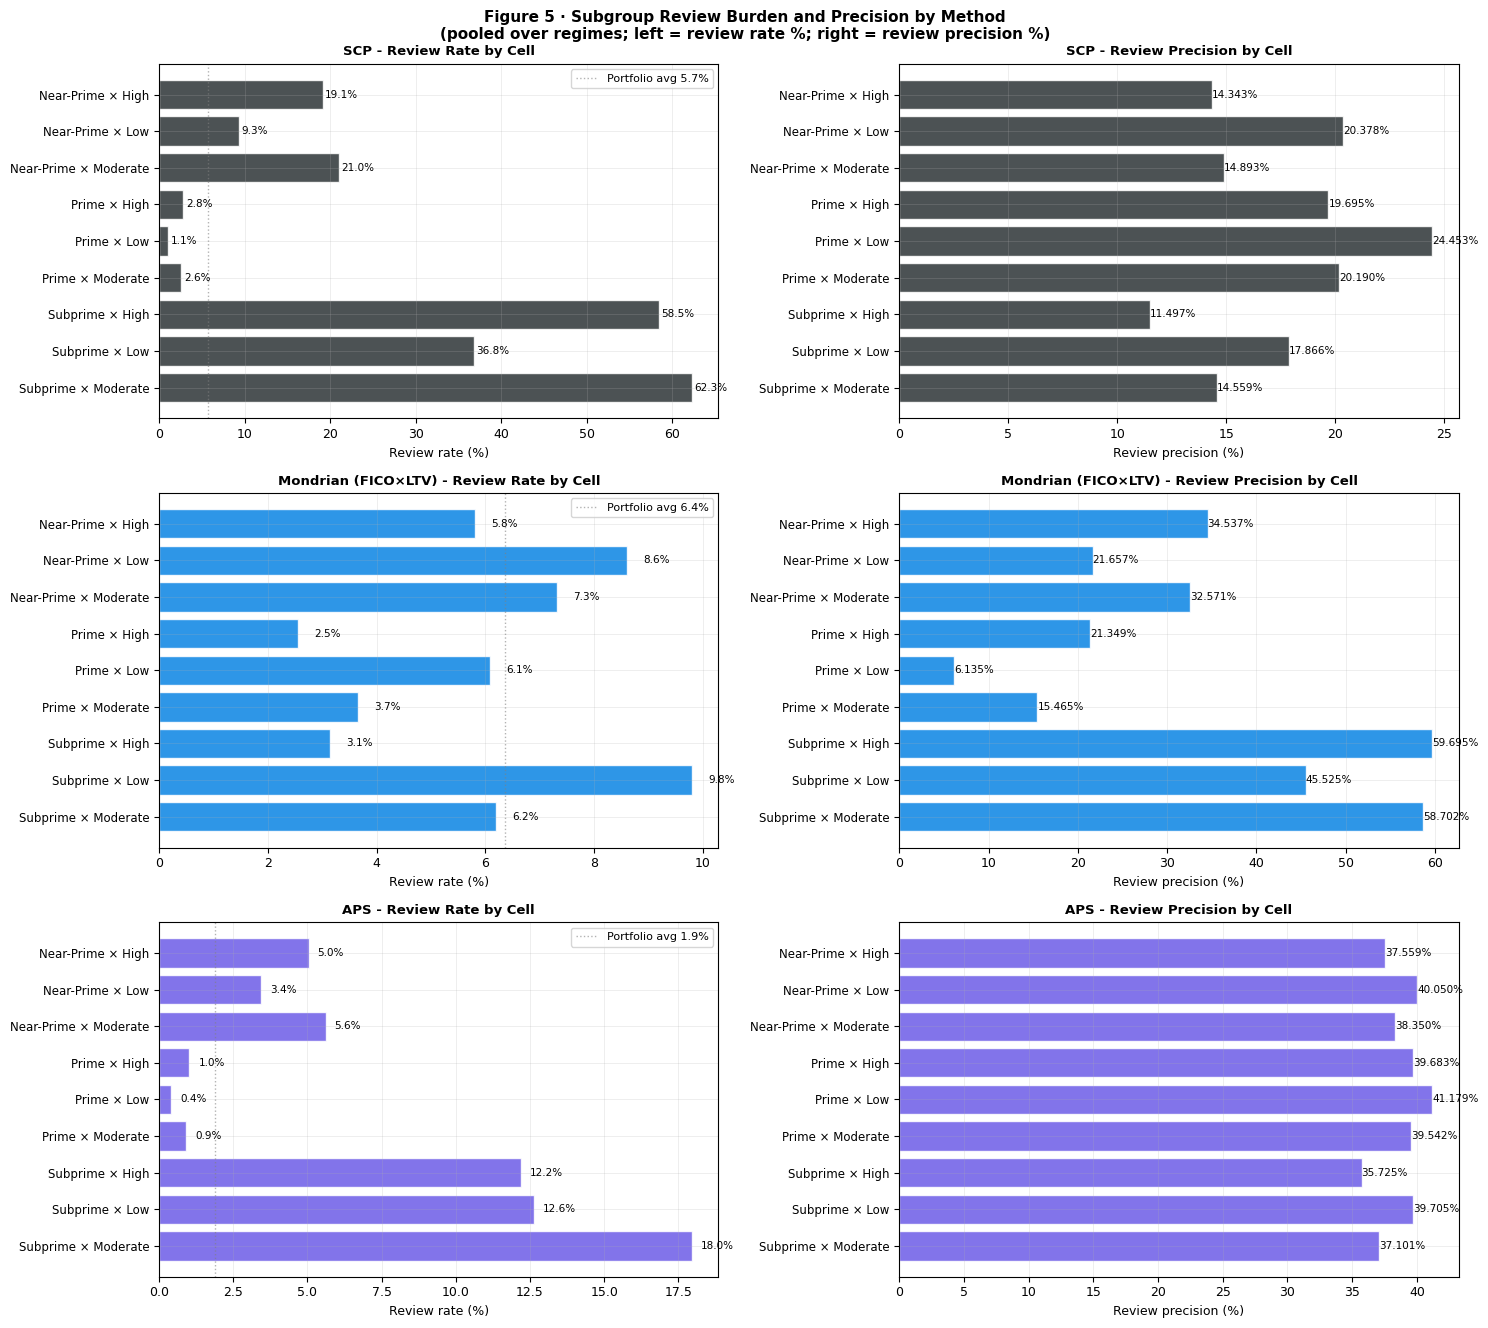

In [ ]:
# ── Figure 5: Subgroup review burden and precision heatmaps ─────────────────
#
# For each FICO×LTV cell, pooled over regimes, compute:
#   - non-auto-clear rate within cell (review or high_risk)
#   - delinquency rate within the non-auto-clear set
#   - review lift within cell (precision / cell positive rate)

FICO_LTV_CELLS = [c for c in df_pd["fico_ltv_group"].unique()
                  if c not in ("Sentinel", None) and str(c) != "nan"]
FICO_LTV_CELLS = sorted(FICO_LTV_CELLS)

fig, axes = plt.subplots(len(AUDIT_METHODS), 2, figsize=(15, 4.5 * len(AUDIT_METHODS)))
fig.suptitle(
    "Figure 5 · Subgroup Review Burden and Precision by Method\n"
    "(pooled over regimes; left = review rate %; right = review precision %)",
    fontsize=11, fontweight="bold"
)

subgroup_rows = []
for ax_row, method in zip(axes, AUDIT_METHODS):
    rcol = ROUTE_COLS[method]
    rv_rates  = []
    rv_precs  = []

    for cell in FICO_LTV_CELLS:
        cell_sub = df_pd[df_pd["fico_ltv_group"] == cell]
        if len(cell_sub) < 200:
            rv_rates.append(np.nan)
            rv_precs.append(np.nan)
            continue

        route    = cell_sub[rcol].values
        y_cell   = cell_sub["y"].values
        rv_mask  = (route == "review") | (route == "high_risk")
        rv_rate  = rv_mask.mean() * 100
        rv_prec  = y_cell[rv_mask].mean() * 100 if rv_mask.sum() > 0 else 0

        rv_rates.append(rv_rate)
        rv_precs.append(rv_prec)

        subgroup_rows.append({
            "method": method, "fico_ltv_group": cell,
            "rv_rate_pct": rv_rate, "rv_precision_pct": rv_prec,
            "pos_rate_pct": y_cell.mean() * 100,
        })

    # Left: review rate
    ax = ax_row[0]
    colors_rv = [METHOD_COLORS[method] if not np.isnan(v) else "#dfe6e9"
                 for v in rv_rates]
    ax.barh(range(len(FICO_LTV_CELLS)), rv_rates,
            color=colors_rv, alpha=0.85, edgecolor="white")
    ax.set_yticks(range(len(FICO_LTV_CELLS)))
    ax.set_yticklabels(FICO_LTV_CELLS, fontsize=8.5)
    ax.invert_yaxis()
    # Compute portfolio-average review rate dynamically from the data
    _port_rv = ((df_pd[ROUTE_COLS[method]] == "review") | (df_pd[ROUTE_COLS[method]] == "high_risk")).mean() * 100
    ax.axvline(_port_rv, color="grey", ls=":", lw=1, alpha=0.6,
               label=f"Portfolio avg {_port_rv:.1f}%")
    ax.set_xlabel("Review rate (%)", fontsize=9)
    ax.set_title(f"{METHOD_LABELS[method]} - Review Rate by Cell", fontsize=9.5, fontweight="bold")
    ax.legend(fontsize=8)

    # Right: precision
    ax = ax_row[1]
    colors_pr = [METHOD_COLORS[method] if not np.isnan(v) else "#dfe6e9"
                 for v in rv_precs]
    ax.barh(range(len(FICO_LTV_CELLS)), rv_precs,
            color=colors_pr, alpha=0.85, edgecolor="white")
    ax.set_yticks(range(len(FICO_LTV_CELLS)))
    ax.set_yticklabels(FICO_LTV_CELLS, fontsize=8.5)
    ax.invert_yaxis()
    ax.set_xlabel("Review precision (%)", fontsize=9)
    ax.set_title(f"{METHOD_LABELS[method]} - Review Precision by Cell", fontsize=9.5, fontweight="bold")

    # Annotate review rate
    for i, (rv, pr) in enumerate(zip(rv_rates, rv_precs)):
        if not np.isnan(rv):
            ax_row[0].text(rv + 0.3, i, f"{rv:.1f}%", va="center", fontsize=7.5)
            ax_row[1].text(pr + 0.003, i, f"{pr:.3f}%", va="center", fontsize=7.5)

fig.tight_layout()
fig.savefig(FIG_DIR / "fig5_subgroup_review_burden.png", bbox_inches="tight", dpi=FIG_DPI)
plt.show()

pd.DataFrame(subgroup_rows).to_csv(NB09_OUT_DIR / "nb09_subgroup_review_burden.csv", index=False)

In [ ]:
# Underlying data for Figure 5
fig5_data = pd.DataFrame(subgroup_rows).copy()
fig5_data["method_label"] = fig5_data["method"].map(METHOD_LABELS)

fig5_data = fig5_data[
    [
        "method", "method_label", "fico_ltv_group",
        "rv_rate_pct", "rv_precision_pct", "pos_rate_pct"
    ]
].sort_values(["method", "fico_ltv_group"]).reset_index(drop=True)

print("=== Data used for Figure 5 ===")
print(fig5_data.to_string(index=False))

=== Data used for Figure 5 ===
           method        method_label        fico_ltv_group  rv_rate_pct  rv_precision_pct  pos_rate_pct
              aps                 APS     Near-Prime × High     5.042351         37.558656      4.334432
              aps                 APS      Near-Prime × Low     3.447227         40.050482      3.203179
              aps                 APS Near-Prime × Moderate     5.614963         38.349853      4.549309
              aps                 APS          Prime × High     1.022540         39.683496      1.539005
              aps                 APS           Prime × Low     0.407753         41.179110      0.704080
              aps                 APS      Prime × Moderate     0.919824         39.542247      1.274872
              aps                 APS       Subprime × High    12.193685         35.724744      7.652564
              aps                 APS        Subprime × Low    12.629943         39.704733      8.044743
              aps       

---
## Section 8 · Monthly Workload Stability (Figure 6)

A lending operation must staff its non-auto-clear queue. This section therefore
asks how that queue share varies month to month within each regime.

The stored series use `review ∪ high_risk` for all methods. APS has the smallest
absolute monthly SD, but this ordering is scale-dependent and does not survive
normalisation by the mean (CV).

This is a workload diagnostic: the stored Figure 6 dashed
10% line marks $(\alpha)$ only and has no nominal interpretation for the non-auto-clear share.

/tmp/ipykernel_348/1442026374.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped = sub.groupby("month").apply(
/tmp/ipykernel_348/1442026374.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped = sub.groupby("month").apply(
/tmp/ipykernel_348/1442026374.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version o

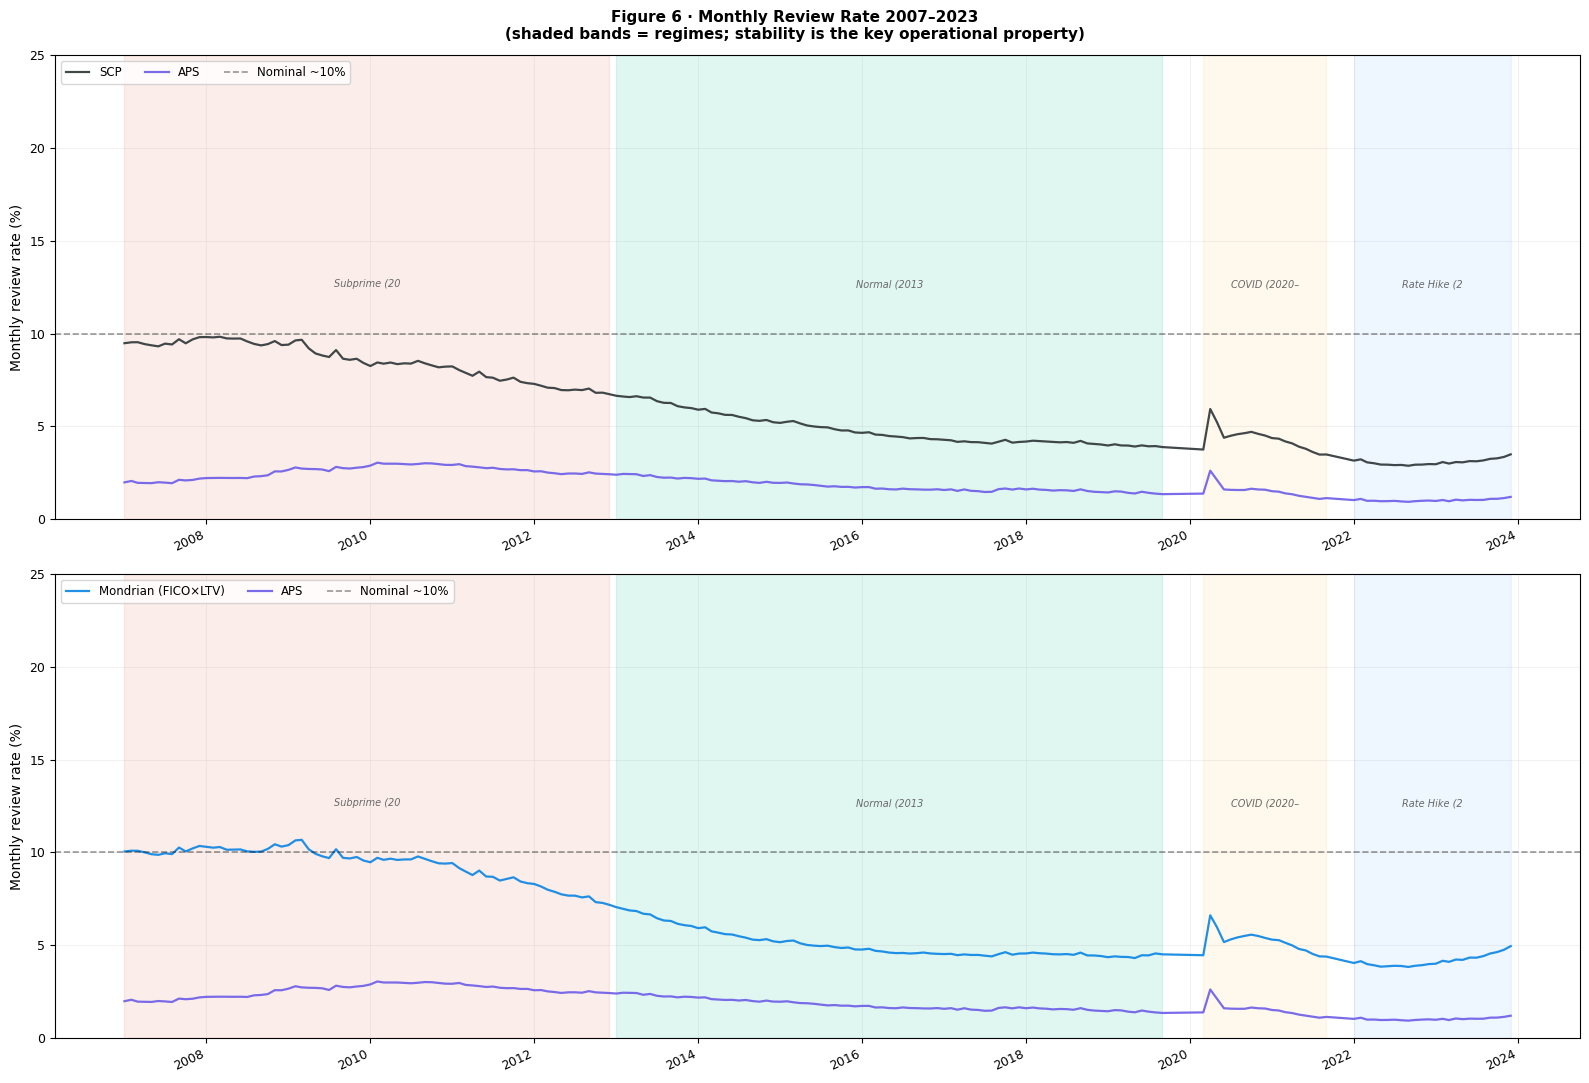

Figure 6 saved.

=== Review-Rate Stability Statistics ===
Method                 Regime                    Mean%    Std%    Min%    Max%     CV
------------------------------------------------------------------------------
  SCP                  Subprime (2007–12)         8.53    0.99    6.74    9.84  0.116
  SCP                  Normal (2013–19)           4.84    0.84    3.89    6.65  0.174
  SCP                  COVID (2020–21)            4.32    0.61    3.48    5.94  0.140
  SCP                  Rate Hike (2022–23)        3.08    0.16    2.88    3.50  0.051
  Mondrian (FICO×LTV)  Subprime (2007–12)         9.39    0.93    7.18   10.68  0.099
  Mondrian (FICO×LTV)  Normal (2013–19)           5.05    0.75    4.31    7.05  0.148
  Mondrian (FICO×LTV)  COVID (2020–21)            5.18    0.57    4.39    6.61  0.109
  Mondrian (FICO×LTV)  Rate Hike (2022–23)        4.16    0.31    3.83    4.95  0.075
  APS                  Subprime (2007–12)         2.55    0.33    1.94    3.05  0.129
  A

In [ ]:
# ── Figure 6: Monthly workload stability ────────────────────────────────────

# Parse obs_month to datetime
if "obs_month" in df_pd.columns:
    try:
        df_pd["obs_month_dt"] = pd.to_datetime(df_pd["obs_month"])
    except Exception:
        df_pd["obs_month_dt"] = pd.to_datetime(df_pd["obs_month"].astype(str).str[:10])
elif "obs_year" in df_pd.columns:
    # Fallback: use obs_year with mid-year date
    df_pd["obs_month_dt"] = pd.to_datetime(df_pd["obs_year"].astype(str) + "-07-01")
    print("Warning: obs_month not available; using obs_year as monthly proxy")

# Monthly non-auto-clear rates per method (review or high_risk)
monthly_records = []
for method, rcol in ROUTE_COLS.items():
    for split in TEST_SPLITS:
        sub = df_pd[df_pd["split"] == split].copy()
        if "obs_month_dt" not in sub.columns:
            continue
        sub["month"] = sub["obs_month_dt"].dt.to_period("M").astype(str)
        grouped = sub.groupby("month").apply(
            lambda g: pd.Series({
                "rv_rate": ((g[rcol] == "review") | (g[rcol] == "high_risk")).mean() * 100,
                "n": len(g),
                "y1_rate": g["y"].mean() * 100,
            })
        ).reset_index()
        grouped["method"] = method
        grouped["split"]  = split
        monthly_records.append(grouped)

monthly_df = pd.concat(monthly_records, ignore_index=True) if monthly_records else pd.DataFrame()

if len(monthly_df) > 0:
    fig, axes = plt.subplots(2, 1, figsize=(16, 11))
    fig.suptitle(
        "Figure 6 · Monthly Review Rate 2007–2023\n"
        "(shaded bands = regimes; stability is the key operational property)",
        fontsize=11, fontweight="bold"
    )

    REGIME_SPANS = []
    for _spl in TEST_SPLITS:
        _m = monthly_df[monthly_df["split"] == _spl]["month"]
        if len(_m) == 0:
            continue
        REGIME_SPANS.append((
            _spl,
            _m.min(),
            _m.max(),
            SPLIT_COLORS[_spl],
            f"{SPLIT_LABELS[_spl]} ({SPLIT_MECH[_spl]})",
        ))

    for ax, methods_shown in zip(axes, [["scp", "aps"], ["mondrian_fico_ltv", "aps"]]):
        for spl, sstart, send, col, lbl in REGIME_SPANS:
            ax.axvspan(pd.Period(sstart, "M").to_timestamp(),
                       pd.Period(send, "M").to_timestamp(),
                       color=col, alpha=0.12, zorder=0)
            ax.text(pd.Period(sstart, "M").to_timestamp() +
                    (pd.Period(send, "M").to_timestamp() - pd.Period(sstart, "M").to_timestamp()) / 2,
                    0.5, lbl[:12], ha="center", fontsize=7, color="dimgray",
                    style="italic", transform=ax.get_xaxis_transform())

        for method in methods_shown:
            mdf = monthly_df[monthly_df["method"] == method].sort_values("month")
            if len(mdf) == 0:
                continue
            dates = pd.PeriodIndex(mdf["month"], freq="M").to_timestamp()
            ax.plot(dates, mdf["rv_rate"], color=METHOD_COLORS[method], lw=1.6,
                    label=METHOD_LABELS[method], alpha=0.9)

        ax.axhline(ALPHA * 100, color="black", ls="--", lw=1.2, alpha=0.4,
           label=f"Nominal ~{ALPHA*100:.0f}%")
        ax.set_ylabel("Monthly review rate (%)", fontsize=10)
        ax.legend(fontsize=8.5, ncol=3)
        ax.set_ylim(0, 25)
        ax.grid(alpha=0.25)
        ax.xaxis.set_major_locator(mpl.dates.YearLocator(2))
        ax.xaxis.set_major_formatter(mpl.dates.DateFormatter("%Y"))
        plt.setp(ax.get_xticklabels(), rotation=25, ha="right", fontsize=9)

    fig.tight_layout()
    fig.savefig(FIG_DIR / "fig6_monthly_workload.png", bbox_inches="tight", dpi=FIG_DPI)
    plt.show()
    print("Figure 6 saved.")
else:
    print("Note: obs_month not available in score files; Figure 6 skipped.")

# ── Stability statistics table ──────────────────────────────────────────────
print("\n=== Review-Rate Stability Statistics ===")
stability_rows = []
if len(monthly_df) > 0:
    print(f"{'Method':<22} {'Regime':<22} {'Mean%':>8} {'Std%':>7} {'Min%':>7} {'Max%':>7} {'CV':>6}")
    print("-" * 78)
    for method in AUDIT_METHODS:
        for split in TEST_SPLITS:
            sub_m = monthly_df[(monthly_df["method"]==method)&(monthly_df["split"]==split)]
            if len(sub_m) < 2:
                continue
            rv = sub_m["rv_rate"]
            mean, std, mn, mx = rv.mean(), rv.std(), rv.min(), rv.max()
            cv = std / mean if mean > 0 else 0
            print(f"  {METHOD_LABELS[method]:<20} {SPLIT_LABELS[split]:<22} "
                  f"{mean:>8.2f} {std:>7.2f} {mn:>7.2f} {mx:>7.2f} {cv:>6.3f}")
            stability_rows.append({
                "method": method, "split": split, "mechanism": SPLIT_MECH[split],
                "mean_rv_pct": mean, "std_rv_pct": std, "min_rv_pct": mn,
                "max_rv_pct": mx, "cv": cv
            })
    pd.DataFrame(stability_rows).to_csv(NB09_OUT_DIR / "nb09_workload_stability.csv", index=False)
else:
    print("Stability statistics not available (obs_month not in score files).")

In [ ]:
# Underlying data for Figure 6: monthly review-rate time series
print("=== Data used for Figure 6: monthly review-rate time series ===")
if "monthly_df" in globals() and len(monthly_df) > 0:
    fig6_monthly_data = monthly_df.copy()
    fig6_monthly_data["method_label"] = fig6_monthly_data["method"].map(METHOD_LABELS)
    fig6_monthly_data["split_label"] = fig6_monthly_data["split"].map(SPLIT_LABELS)
    fig6_monthly_data = fig6_monthly_data[
        ["method", "method_label", "split", "split_label", "month", "rv_rate", "n", "y1_rate"]
    ].sort_values(["method", "split", "month"]).reset_index(drop=True)
    print(fig6_monthly_data.to_string(index=False))
else:
    print("monthly_df is empty or not available.")

=== Data used for Figure 6: monthly review-rate time series ===
           method        method_label          split         split_label   month   rv_rate        n  y1_rate
              aps                 APS     test_covid     COVID (2020–21) 2020-03  1.381255 513591.0 5.240746
              aps                 APS     test_covid     COVID (2020–21) 2020-04  2.616490 509079.0 5.173264
              aps                 APS     test_covid     COVID (2020–21) 2020-05  2.121061 498194.0 3.198754
              aps                 APS     test_covid     COVID (2020–21) 2020-06  1.603883 492804.0 2.025958
              aps                 APS     test_covid     COVID (2020–21) 2020-07  1.583244 494049.0 1.714405
              aps                 APS     test_covid     COVID (2020–21) 2020-08  1.574984 499624.0 1.517341
              aps                 APS     test_covid     COVID (2020–21) 2020-09  1.576051 504108.0 1.386608
              aps                 APS     test_covid     COVID (

---
## Section 9 · Exploratory Cost Sensitivity

This auxiliary analysis assigns normalized loss to false auto-clears and to loan-months that are not auto-cleared:

$$
L_m(r) = P_m(\text{auto-clear}, Y=1) + r\, P_m(\text{not auto-clear}), \qquad r = \frac{c_{\text{review}}}{c_{\text{FN}}}.
$$

Reject-option theory motivates assigning an explicit cost to rejection or abstention (Chow, 1957, 1970; Herbei & Wegkamp, 2006). The expression above is nevertheless a simplified sensitivity device, not a calibrated mortgage-loss model: it imposes no empirical loss-severity or review-cost estimate, and the code assigns the same non-auto-clear cost to review and escalation.

The code sweeps $r$ from 0.5% to 10%. No empirical interpretation is attached to that range.

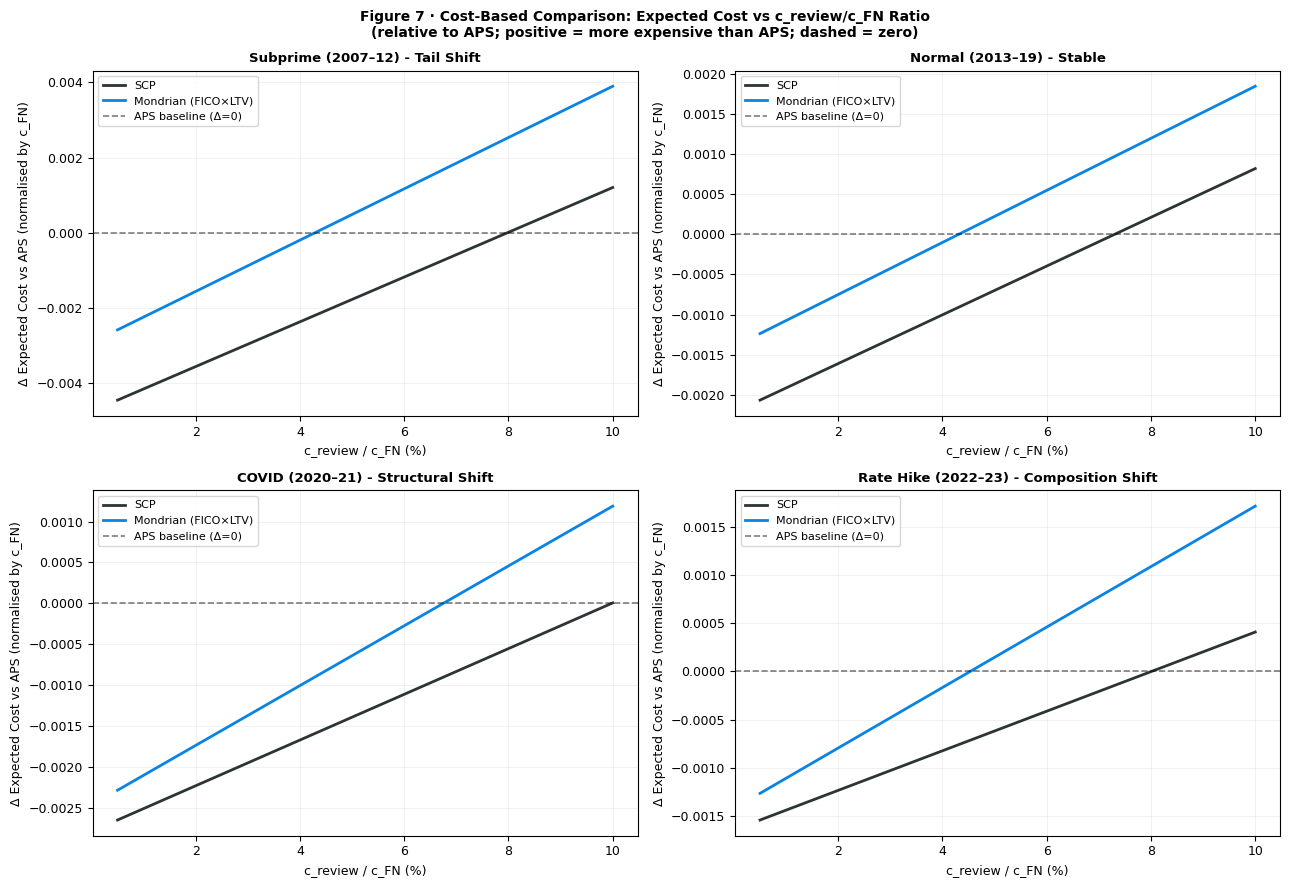

In [ ]:
# ── Section 9: Cost-based comparison ─────────────────────────────────────────
#
# Normalized expected cost per observation:
#   cost(method) = c_FN * P(auto_clear AND y=1) + c_review * P(review or high_risk)
#
# where:
#   c_FN     = cost of false auto-clear (future delinquent waved through)
#   c_review = cost of manual review / escalation
#
# Normalization by c_FN and let:
#   r = c_review / c_FN

COST_RATIOS = np.linspace(0.005, 0.10, 50)   # c_review / c_FN from 0.5% to 10%

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle(
    "Figure 7 · Cost-Based Comparison: Expected Cost vs c_review/c_FN Ratio\n"
    "(relative to APS; positive = more expensive than APS; dashed = zero)",
    fontsize=10, fontweight="bold"
)

cost_rows = []
for ax, split in zip(axes.flatten(), TEST_SPLITS):
    sub    = df_pd[df_pd["split"] == split]
    y      = sub["y"].values
    n      = len(sub)

    for method, rcol in ROUTE_COLS.items():
        route   = sub[rcol].values
        ac_mask = route == "auto_clear"
        rv_mask = (route == "review") | (route == "high_risk")

        # P(FN) = P(auto_clear AND y=1)
        p_fn     = (ac_mask & (y == 1)).mean()
        # P(non-auto-clear) = P(review or high_risk)
        p_rv     = rv_mask.mean()

        rel_costs = []
        for r in COST_RATIOS:
            # Normalised cost = r * P(non-auto-clear) + 1 * P(FN)
            cost = r * p_rv + 1.0 * p_fn
            rel_costs.append(cost)
            cost_rows.append({
                "split": split, "method": method, "r": r,
                "cost": cost, "p_fn": p_fn, "p_rv": p_rv,
            })

        if method != "aps":
            # Compute APS cost for reference
            aps_route = sub[ROUTE_COLS["aps"]].values
            aps_ac    = aps_route == "auto_clear"
            aps_fn    = (aps_ac & (y == 1)).mean()
            aps_rv    = ((aps_route == "review") | (aps_route == "high_risk")).mean()
            aps_costs = [r * aps_rv + aps_fn for r in COST_RATIOS]
            delta_costs = [rel - aps for rel, aps in zip(rel_costs, aps_costs)]
            ax.plot(COST_RATIOS * 100, delta_costs,
                    color=METHOD_COLORS[method], lw=2.0, label=METHOD_LABELS[method])

    ax.axhline(0, color="black", ls="--", lw=1.2, alpha=0.5, label="APS baseline (Δ=0)")
    ax.set_xlabel("c_review / c_FN (%)", fontsize=9)
    ax.set_ylabel("Δ Expected Cost vs APS (normalised by c_FN)", fontsize=9)
    ax.set_title(f"{SPLIT_LABELS[split]} - {SPLIT_MECH[split]}", fontsize=9.5, fontweight="bold")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.25)

fig.tight_layout()
fig.savefig(FIG_DIR / "fig7_cost_comparison.png", bbox_inches="tight", dpi=FIG_DPI)
plt.show()
pd.DataFrame(cost_rows).to_csv(NB09_OUT_DIR / "nb09_cost_comparison.csv", index=False)

---
## Section 10 · Locked Operational Findings

> **Legacy-output note.** The stored printout below uses older terminology:
> "equal review rate" means a matched **non-auto-clear budget**; the NB08 5% split
> has **higher APS miscoverage above 5%**, not below it; and Mondrian's negative
> $\Delta$ is a **selection-efficiency deficit at that budget**, not a claim of
> global operational sub-optimality.

In [ ]:
# ── 10.1 · Print consolidated operational findings ──────────────────────────
print("=" * 90)
print("NB09 LOCKED OPERATIONAL FINDINGS")
print("=" * 90)

print("\nFinding D1 - Routing safety: false auto-clear rates")
for split in TEST_SPLITS:
    fac_scp  = rm_df[(rm_df["method"]=="scp")&(rm_df["split"]==split)]["fac_pct"].values[0]
    fac_mond = rm_df[(rm_df["method"]=="mondrian_fico_ltv")&(rm_df["split"]==split)]["fac_pct"].values[0]
    fac_aps  = rm_df[(rm_df["method"]=="aps")&(rm_df["split"]==split)]["fac_pct"].values[0]
    print(f"  {SPLIT_LABELS[split]:<22}: SCP={fac_scp:>7.3f}%   Mondrian={fac_mond:>7.3f}%   APS={fac_aps:>7.3f}%")
print(f"  NB08 cross-reference: APS auto-clear band is p_hat_cal < {aps_lo:.5f}; "
      f"NB08 flags the APS low-risk tail at p_hat_cal < {APS_RISK_TAIL_THRESHOLD:.2f}.")

print("\nFinding D2 - CP vs probability-threshold baseline at equal review rate")
for split in TEST_SPLITS:
    for method in AUDIT_METHODS:
        row = er_df[(er_df["method"] == method) & (er_df["split"] == split)]
        if not row.empty:
            r = row.iloc[0]
            print(
                f"  {METHOD_LABELS[method]:<22} {SPLIT_LABELS[split]:<22}: "
                f"review={r['rv_rate_pct']:>6.2f}%   "
                f"CP_cap={r['cp_capture_pct']:>7.2f}%   "
                f"BL_cap={r['baseline_capture_pct']:>7.2f}%   "
                f"Δ={r['delta_pp']:>+6.3f}pp"
            )

print("\nFinding D3 - Mondrian Delta < 0 at equal review rate (operationally sub-optimal)")
mond_er = er_df[er_df["method"] == "mondrian_fico_ltv"]
print(f"  Mondrian Delta range: {mond_er['delta_pp'].min():+.2f} to {mond_er['delta_pp'].max():+.2f} pp")
for split in TEST_SPLITS:
    d = mond_er[mond_er["split"] == split]["delta_pp"]
    if not d.empty:
        print(f"  {SPLIT_LABELS[split]:<22}: Delta={d.values[0]:>+6.2f}pp")

print("\nFinding D4 - APS operating profile: small-queue, high-precision, lower-capture, high-FAC")
for split in TEST_SPLITS:
    rv_aps  = rm_df[(rm_df["method"]=="aps")&(rm_df["split"]==split)]["rv_rate_pct"].values[0]
    prec_aps = rm_df[(rm_df["method"]=="aps")&(rm_df["split"]==split)]["rv_precision_pct"].values[0]
    print(f"  {SPLIT_LABELS[split]:<22}: APS review rate={rv_aps:>6.2f}%   review precision={prec_aps:>7.3f}%")

if stability_rows:
    print("\nReview-rate stability (within-regime monthly std, supporting diagnostic):")
    for method in AUDIT_METHODS:
        vals = [r["std_rv_pct"] for r in stability_rows if r["method"] == method]
        if len(vals):
            print(f"  {METHOD_LABELS[method]:<22}: mean monthly std = {np.mean(vals):.2f} pp")

NB09 LOCKED OPERATIONAL FINDINGS

Finding D1 - Routing safety: false auto-clear rates
  Subprime (2007–12)    : SCP= 37.949%   Mondrian= 45.159%   APS= 56.702%
  Normal (2013–19)      : SCP= 41.878%   Mondrian= 47.240%   APS= 56.399%
  COVID (2020–21)       : SCP= 52.309%   Mondrian= 54.236%   APS= 69.037%
  Rate Hike (2022–23)   : SCP= 49.193%   Mondrian= 51.336%   APS= 65.015%
  NB08 cross-reference: APS auto-clear band is p_hat_cal < 0.10005; NB08 flags the APS low-risk tail at p_hat_cal < 0.05.

Finding D2 - CP vs probability-threshold baseline at equal review rate
  SCP                    Subprime (2007–12)    : review=  8.52%   CP_cap=  62.05%   BL_cap=  62.05%   Δ=+0.000pp
  Mondrian (FICO×LTV)    Subprime (2007–12)    : review=  9.38%   CP_cap=  54.84%   BL_cap=  63.58%   Δ=-8.739pp
  APS                    Subprime (2007–12)    : review=  2.56%   CP_cap=  43.30%   BL_cap=  43.30%   Δ=+0.000pp
  SCP                    Normal (2013–19)      : review=  4.81%   CP_cap=  58.12%   B

## Appendix · References

---

### Conformal Prediction - Foundations

- Vovk, V., Gammerman, A., & Shafer, G. (2005). Algorithmic learning in a random world (1st ed.). Springer. https://doi.org/10.1007/b106715

- Papadopoulos, H., Proedrou, K., Vovk, V., & Gammerman, A. (2002). Inductive confidence machines for regression. In T. Elomaa, H. Mannila, & H. Toivonen (Eds.), Machine learning: Ecml 2002 (pp. 345–356, Vol. 2430). Springer. https://doi.org/10.1007/3-540-36755-1_29

- Sadinle, M., Lei, J., & Wasserman, L. (2019). Least ambiguous set-valued classifiers with bounded error levels. Journal of the American Statistical Association, 114(525), 223–234. https://doi.org/10.1080/01621459.2017.1395341

---

### Conformal Prediction - Adaptive and Mondrian Methods

- Romano, Y., Sesia, M., & Candès, E. J. (2020). Classification with valid and adaptive coverage. In H. Larochelle, M. Ranzato, R. Hadsell, M.-F. Balcan, & H.-T. Lin (Eds.), Advances in neural information processing systems (pp. 3581–3591, Vol. 33). Curran Associates, Inc. https://proceedings.neurips.cc/paper/2020/hash/244edd7e85dc81602b7615cd705545f5-Abstract.html

- Gibbs, I., & Candès, E. J. (2021). Adaptive conformal inference under distribution shift. Advances in
Neural Information Processing Systems, 34, 1660–1672. https://proceedings.neurips.cc/paper/2021/hash/0d441de75945e5acbc865406fc9a2559-Abstract.html

- Gibbs, I., & Candès, E. J. (2024). Conformal inference for online prediction with arbitrary distribution
shifts. Journal of Machine Learning Research, 25(162), 1–36. https://www.jmlr.org/papers/v25/22-1218.html

---

### Reject-Option Classification and Selective Classification

- Chow, C. K. (1957). An optimum character recognition system using decision functions. IRE Trans-
actions on Electronic Computers, EC-6(4), 247–254. https://doi.org/10.1109/TEC.1957.5222035

- Chow, C. K. (1970). On optimum recognition error and reject tradeoff. IEEE Transactions on Informa-
tion Theory, 16(1), 41–46. https://doi.org/10.1109/TIT.1970.1054406

- Herbei, R., & Wegkamp, M. H. (2006). Classification with reject option. Canadian Journal of Statistics, 34(4), 709–721. https://doi.org/10.1002/cjs.5550340410

- El-Yaniv, R., & Wiener, Y. (2010). On the foundations of noise-free selective classification. Journal
of Machine Learning Research, 11(53), 1605–1641. https://www.jmlr.org/papers/v11/el-yaniv10a.html

- Geifman, Y., & El-Yaniv, R. (2017). Selective classification for deep neural networks. Advances in
Neural Information Processing Systems, 30, 4878–4887. https://proceedings.neurips.cc/paper/2017/hash/4a8423d5e91fda00bb7e46540e2b0cf1-Abstract.html

- Franc, V., Prusa, D., & Voracek, V. (2023). Optimal strategies for reject option classifiers. Journal of
Machine Learning Research, 24(11), 1–49. https://www.jmlr.org/papers/v24/21-0048.html

---

### Decision-Theoretic and Operational Conformal Prediction

- Kiyani, S., Pappas, G. J., Roth, A., & Hassani, H. (2025). Decision theoretic foundations for conformal
prediction: Optimal uncertainty quantification for risk-averse agents. In A. Singh, M. Fazel,
D. Hsu, S. Lacoste-Julien, F. Berkenkamp, T. Maharaj, K. Wagstaff, & J. Zhu (Eds.), Proceedings
of the 42nd international conference on machine learning (pp. 30943–30965, Vol. 267). PMLR.
https://proceedings.mlr.press/v267/kiyani25a.html